In [1]:
# Generated from output/jupyter-notebook/agro-yard-paper-benchmark-and-selection.ipynb
# Run as a percent script in editors that support `# %%` cells, or as plain Python.


# Experiment: Agro Yard Paper Benchmark and Selection

**Objetivo**

Implementar de ponta a ponta o desenho experimental de `paper/Artigo.md` em um único notebook auditável, cobrindo benchmarking de métodos, ISA, seleção por features, validade do benchmark sintético e geração de instâncias-filhas.

**O que este notebook cobre**

- `E0`: reprodutibilidade do benchmark, validação estrutural e replay do FIFO
- `E1`: comparação principal entre `M0`, `M1`, `M2`, `M3`, `M4` e `Mref`
- `E2/E2b`: trade-offs periódico vs evento e sensibilidade computacional
- `E3`: ISA com `PCA`, `UMAP`, `HDBSCAN` e solver footprints
- `E4`: selector explicativo com `SHAP` e exportação ASlib-like
- `E5`: scorecard de validade sintética com `MMD`, `C2ST` e `density ratio`
- `E6`: propostas e geração de instâncias `graded` e `discriminating`

**Modo de uso**

Este é o notebook canônico do paper. Ele pode:

- analisar o snapshot oficial já presente no workspace
- recomputar as tabelas e figuras do artigo de forma reproduzível
- regenerar artefatos auxiliares do pipeline analítico quando necessário

O notebook concentra a implementação do paper em um único fluxo executável e usa apenas módulos e dados já versionados neste workspace para leitura, validação, benchmarking, seleção e análise do espaço de instâncias.


In [2]:
# Setup: notebook runtime, paths and shared backend
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib
from IPython import get_ipython
from IPython.display import Markdown, display

NON_INTERACTIVE_CLI = __name__ == "__main__" and "ipykernel" not in sys.modules
if NON_INTERACTIVE_CLI:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "instances").exists()
            and (candidate / "catalog").exists()
            and (candidate / "tools").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import experiments.agro_yard_paper as paper

paper = paper.reload_package()
repl = paper.repl
solver_smoke = paper.solver_smoke

if NON_INTERACTIVE_CLI:
    plt.show = lambda *args, **kwargs: None
else:
    shell = get_ipython()
    if shell is not None:
        shell.run_line_magic("matplotlib", "inline")

PIPELINE_CONFIG = dict(paper.DEFAULT_PIPELINE_CONFIG)
ANALYSIS_ROOT = paper.prepare_analysis_root(PIPELINE_CONFIG)
ARTIFACT_DIR = (
    ANALYSIS_ROOT / "output" / "jupyter-notebook" / "instance_validation_analysis_artifacts"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SEED = paper.SEED
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

STAGE_ORDER = paper.STAGE_ORDER
REGIME_ORDER = paper.REGIME_ORDER
SCALE_ORDER = paper.SCALE_ORDER


## Plan

1. Carregar o snapshot do benchmark e expor o backend analítico compartilhado.
2. Auditar a release observada, reconciliar audits e validar o replay do FIFO.
3. Medir deslocamento nominal -> observado, consistência relacional e qualidade sintética do release.
4. Construir o benchmarking dos métodos do artigo com utilidade, regret e profiles.
5. Rodar `E2/E2b` para comparar mecanismos reativos e sensibilidade computacional.
6. Projetar o espaço de instâncias com `PCA/UMAP`, clusterizar com `HDBSCAN` e extrair footprints.
7. Treinar o selector explicativo, exportar o cenário ASlib-like e sumarizar `SHAP`.
8. Gerar scorecards finais, propostas `graded/discriminating` e bundles derivados reproduzíveis.


In [3]:
# Bootstrap the notebook workspace from the shared REPL backend
release = paper.load_release_bundle(root=ANALYSIS_ROOT, artifact_dir=ARTIFACT_DIR)
CTX = release.ctx
SUMMARY = release.summary
NOTEBOOK_CTX = dict(CTX)

validation_observed = release.validation_observed.copy()
validation_nominal_style = release.validation_nominal_style.copy()
g2milp_contract = dict(release.g2milp_contract)

params = release.params.copy()
catalog = release.catalog.copy()
family_summary = release.family_summary.copy()
observed_noise_manifest = release.observed_noise_manifest
manifest = release.manifest

jobs = release.jobs.copy()
jobs_enriched = release.jobs_enriched.copy()
operations = release.operations.copy()
eligible = release.eligible.copy()
machines = release.machines.copy()
precedences = release.precedences.copy()
downtimes = release.downtimes.copy()
events = release.events.copy()
schedule = release.schedule.copy()
job_metrics = release.job_metrics.copy()
due_audit = release.due_audit.copy()
proc_audit = release.proc_audit.copy()
proc_audit_enriched = release.proc_audit_enriched.copy()
congestion = release.congestion.copy()

structural_report = release.structural_report.copy()
event_report = release.event_report.copy()
audit_reconciliation = release.audit_reconciliation.copy()
regime_checks = release.regime_checks.copy()
fifo_schema_report = release.fifo_schema_report.copy()
release_consistency_report = release.release_consistency_report.copy()
utilization = release.utilization.copy()
instance_space_features = release.instance_space_features.copy()
instance_space_pairs = release.instance_space_pairs.copy()
instance_space_summary = release.instance_space_summary.copy()
instance_space_knn_profile = release.instance_space_knn_profile.copy()
instance_space_knn_regime_composition = release.instance_space_knn_regime_composition.copy()
instance_space_knn_scale_composition = release.instance_space_knn_scale_composition.copy()
diagnostics = release.diagnostics.copy() if hasattr(release.diagnostics, "copy") else dict(release.diagnostics)
unload = release.unload.copy()

inventory_summary = pd.DataFrame([SUMMARY])
pipeline_summary = pd.DataFrame(
    [
        {
            "analysis_root": str(ANALYSIS_ROOT),
            "artifact_dir": str(ARTIFACT_DIR),
            "generate_observed_release": bool(PIPELINE_CONFIG["generate_observed_release"]),
            "source_root": str(PIPELINE_CONFIG["source_root"] or ""),
            "target_root": str(PIPELINE_CONFIG["target_root"]),
            "sample_instance_id": str(PIPELINE_CONFIG["sample_instance_id"]),
        }
    ]
)
display(pipeline_summary)
display(inventory_summary)
display(
    Markdown(
        """
**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_space_coverage()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01", ctx=NOTEBOOK_CTX)`
"""
    )
)


,analysis_root,artifact_dir,generate_observed_release,source_root,target_root,sample_instance_id
0,/home/marcusvinicius/Repositorios/PequiFlux/ag...,/home/marcusvinicius/Repositorios/PequiFlux/ag...,False,,/home/marcusvinicius/Repositorios/PequiFlux/ag...,GO_XS_DISRUPTED_01


,dataset_version,instance_count,job_count,operation_count,eligible_rows,machine_rows,structural_pass_rate,release_consistency_checks_pass,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,fifo_schema_checks_pass,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,instance_space_exact_duplicate_checks_pass,instance_space_duplicate_like_checks_pass,instance_space_nearest_neighbor_distance_min,g2milp_role
0,1.1.0-observed,36,1848,7392,21167,306,1.0,False,1.0,1.0,0.4848,0.4995,True,True,True,False,True,True,2.322821,base_dataset_for_g2milp_instance_generation



**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_space_coverage()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01", ctx=NOTEBOOK_CTX)`


In [4]:
# Release metadata and provenance checks
noise_manifest_summary = pd.DataFrame(
    [
        {
            "dataset_version": manifest["dataset_version"],
            "official_dataset_role": manifest["official_dataset_role"],
            "noise_model_id": observed_noise_manifest.get("model_id"),
            "noise_global_seed": observed_noise_manifest.get("global_seed"),
            "parent_dataset_version": manifest.get("parent_dataset_version"),
            "generator_model": observed_noise_manifest.get(
                "generator_model", "ChatGPT 5.4 PRO"
            ),
        }
    ]
)

display(params.head())
display(noise_manifest_summary)
display(release_consistency_report)
display(pd.DataFrame([g2milp_contract]).iloc[:, :8])

release_consistency_report.to_csv(
    ARTIFACT_DIR / "release_consistency_report.csv", index=False
)

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
0,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_01,L,balanced,1,41111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,817207134
1,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_02,L,balanced,2,42111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,3851404905
2,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_03,L,balanced,3,43111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,482397280
3,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_01,L,disrupted,1,41333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,569216366
4,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_02,L,disrupted,2,42333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,1131596359


,dataset_version,official_dataset_role,noise_model_id,noise_global_seed,parent_dataset_version,generator_model
0,1.1.0-observed,base_dataset_for_g2milp_instance_generation,pequiflux_observed_noise_v1_1,20260327,1.0.0,ChatGPT 5.4 PRO


,check_name,expected,observed,pass
0,manifest_dataset_version_matches_instance_params,1.1.0-observed,1.1.0-observed,True
1,manifest_parent_dataset_version_matches_instan...,1.0.0,1.0.0,True
2,manifest_noise_model_id_matches_instance_params,pequiflux_observed_noise_v1_1,pequiflux_observed_noise_v1_1,True
3,noise_manifest_model_id_matches_root_manifest,pequiflux_observed_noise_v1_1,pequiflux_observed_noise_v1_1,True
4,noise_manifest_repository_url_matches_root_man...,https://github.com/PequiFlux/agro_yard_dfjsp_b...,https://github.com/PequiFlux/agro_yard_dfjsp_b...,True
5,noise_manifest_release_root_matches_repo_root,/home/marcusvinicius/Repositorios/PequiFlux/ag...,/home/marcusvinicius/Repositorios/PequiFlux/ag...,False
6,noise_manifest_generated_with_matches_root_man...,ChatGPT 5.4 PRO,ChatGPT 5.4 PRO,True


,official_dataset_role,parent_dataset_version,generator_model_family,dataset_is_frozen_parent,required_child_lineage_fields,minimum_child_validation_requirements,documentation_ref
0,base_dataset_for_g2milp_instance_generation,1.1.0-observed,G2MILP,True,"[parent_dataset_name, parent_dataset_version, ...",[four_operations_per_job_or_declared_structura...,docs/g2milp_generation_contract.md


**Como ler as tabelas acima**

- `noise_manifest_summary` resume a versão oficial, a linhagem e o modelo gerador da camada observacional
- `release_consistency_report` formaliza a governança do release: `manifest.json` raiz, `params.json` das instâncias e `observed_noise_manifest.json`
- para publicação, o desejável é que todos os checks dessa tabela estejam em `pass = True`
- no release oficial atual, isso de fato ocorre; em particular, não há divergência entre a `dataset_version` do `manifest.json` raiz e a `dataset_version` declarada nos `params.json`

## Inventory and structural context

Esta seção responde:

- quantas instâncias, jobs, operações, máquinas e linhas elegíveis existem
- como as famílias `XS/S/M/L` e os regimes `balanced/peak/disrupted` estão distribuídos
- se os artefatos de auditoria e catálogo estão completos

,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
0,GO_L_BALANCED_01,instances/GO_L_BALANCED_01,L,balanced,1,41111,72,13,4,3,6,0,0.0278,0.7500,38.78,24.08,670,52.99,68,0.0,metaheuristic
1,GO_L_BALANCED_02,instances/GO_L_BALANCED_02,L,balanced,2,42111,72,13,4,3,6,0,0.0278,0.7500,37.89,24.33,681,58.69,87,0.0,metaheuristic
2,GO_L_BALANCED_03,instances/GO_L_BALANCED_03,L,balanced,3,43111,72,13,4,3,6,0,0.0278,0.7500,38.81,25.91,655,50.44,57,0.0,metaheuristic
3,GO_L_DISRUPTED_01,instances/GO_L_DISRUPTED_01,L,disrupted,1,41333,96,13,4,3,6,3,0.1979,0.5938,38.57,28.56,617,101.03,148,0.0,metaheuristic
4,GO_L_DISRUPTED_02,instances/GO_L_DISRUPTED_02,L,disrupted,2,42333,96,13,4,3,6,2,0.1771,0.6354,37.85,24.08,591,93.40,150,0.0,metaheuristic
5,GO_L_DISRUPTED_03,instances/GO_L_DISRUPTED_03,L,disrupted,3,43333,96,13,4,3,6,2,0.1875,0.5938,37.96,25.93,601,93.71,141,0.0,metaheuristic
6,GO_L_PEAK_01,instances/GO_L_PEAK_01,L,peak,1,41222,96,13,4,3,6,0,0.0833,0.6562,38.25,25.81,643,94.60,163,0.0,metaheuristic
7,GO_L_PEAK_02,instances/GO_L_PEAK_02,L,peak,2,42222,96,13,4,3,6,0,0.1354,0.7083,38.06,25.49,662,73.54,112,0.0,metaheuristic
8,GO_L_PEAK_03,instances/GO_L_PEAK_03,L,peak,3,43222,96,13,4,3,6,0,0.0729,0.6354,38.07,23.50,671,78.89,127,0.0,metaheuristic
9,GO_M_BALANCED_01,instances/GO_M_BALANCED_01,M,balanced,1,31111,48,9,3,2,4,0,0.0417,0.7292,37.79,27.74,673,55.35,68,0.0,hybrid


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


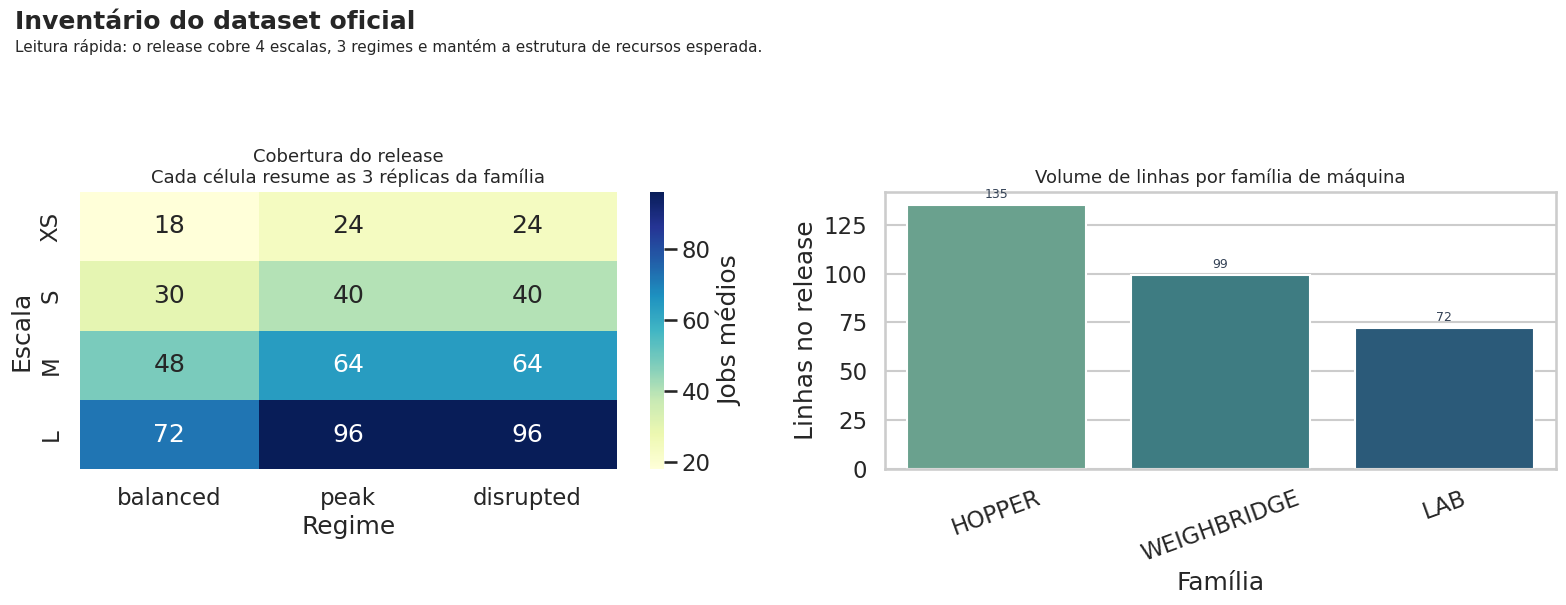

In [5]:
display(catalog.sort_values(["scale_code", "regime_code", "replicate"]).head(12))
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_inventory_overview(ctx=NOTEBOOK_CTX, save=False)
plt.show()

**Como ler a figura acima**

- o heatmap da esquerda mostra cobertura do release por família `escala x regime`
- as barras da direita mostram quantas linhas de recurso existem por família de máquina no release consolidado
- a figura serve como checagem de inventário, não de desempenho

## Structural validation and auditability

Aqui reaplicamos o verificador estrutural do release e complementamos com:

- executabilidade formal do baseline FIFO contra o schema
- consistência de eventos
- margem do prazo sobre o lower bound nominal
- reconciliação auditável entre arquivos centrais e CSVs de audit

,instance_id,issue_count,issues,status,scale_code,regime_code
0,GO_L_BALANCED_01,0,,PASS,L,balanced
1,GO_L_BALANCED_02,0,,PASS,L,balanced
2,GO_L_BALANCED_03,0,,PASS,L,balanced
3,GO_L_DISRUPTED_01,0,,PASS,L,disrupted
4,GO_L_DISRUPTED_02,0,,PASS,L,disrupted
5,GO_L_DISRUPTED_03,0,,PASS,L,disrupted
6,GO_L_PEAK_01,0,,PASS,L,peak
7,GO_L_PEAK_02,0,,PASS,L,peak
8,GO_L_PEAK_03,0,,PASS,L,peak
9,GO_M_BALANCED_01,0,,PASS,M,balanced


,instance_id,eligible_assignment_ok,release_time_ok,precedence_ok,machine_overlap_ok,downtime_ok,ineligible_assignments,release_time_violations,precedence_violations,machine_overlap_violations,downtime_violations,scale_code,regime_code
0,GO_L_BALANCED_01,True,True,True,True,True,0,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,True,True,True,True,True,0,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,True,True,True,True,True,0,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,True,True,True,True,True,0,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,True,True,True,True,True,0,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,True,True,True,True,True,0,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,True,True,True,True,True,0,0,0,0,0,L,peak
7,GO_L_PEAK_02,True,True,True,True,True,0,0,0,0,0,L,peak
8,GO_L_PEAK_03,True,True,True,True,True,0,0,0,0,0,L,peak
9,GO_M_BALANCED_01,True,True,True,True,True,0,0,0,0,0,M,balanced


,instance_id,job_visible_mismatch,job_arrival_mismatch,machine_down_missing,machine_up_missing,scale_code,regime_code
0,GO_L_BALANCED_01,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,0,0,0,0,L,peak
7,GO_L_PEAK_02,0,0,0,0,L,peak
8,GO_L_PEAK_03,0,0,0,0,L,peak
9,GO_M_BALANCED_01,0,0,0,0,M,balanced


,instance_id,due_match_share,proc_match_share,scale_code,regime_code
0,GO_L_BALANCED_01,1.0,1.0,L,balanced
1,GO_L_BALANCED_02,1.0,1.0,L,balanced
2,GO_L_BALANCED_03,1.0,1.0,L,balanced
3,GO_L_DISRUPTED_01,1.0,1.0,L,disrupted
4,GO_L_DISRUPTED_02,1.0,1.0,L,disrupted
5,GO_L_DISRUPTED_03,1.0,1.0,L,disrupted
6,GO_L_PEAK_01,1.0,1.0,L,peak
7,GO_L_PEAK_02,1.0,1.0,L,peak
8,GO_L_PEAK_03,1.0,1.0,L,peak
9,GO_M_BALANCED_01,1.0,1.0,M,balanced


,index,scale_code,regime_code,mean,min,median,max
0,0,L,balanced,249.80,154,251.0,301
1,1,L,disrupted,258.99,141,264.0,353
2,2,L,peak,257.97,172,264.0,314
3,3,M,balanced,239.47,146,243.0,295
4,4,M,disrupted,262.74,158,269.0,331
5,5,M,peak,246.40,162,249.0,327
6,6,S,balanced,248.60,179,254.5,288
7,7,S,disrupted,255.80,189,261.0,331
8,8,S,peak,246.94,173,254.0,300
9,9,XS,balanced,233.09,169,237.5,268


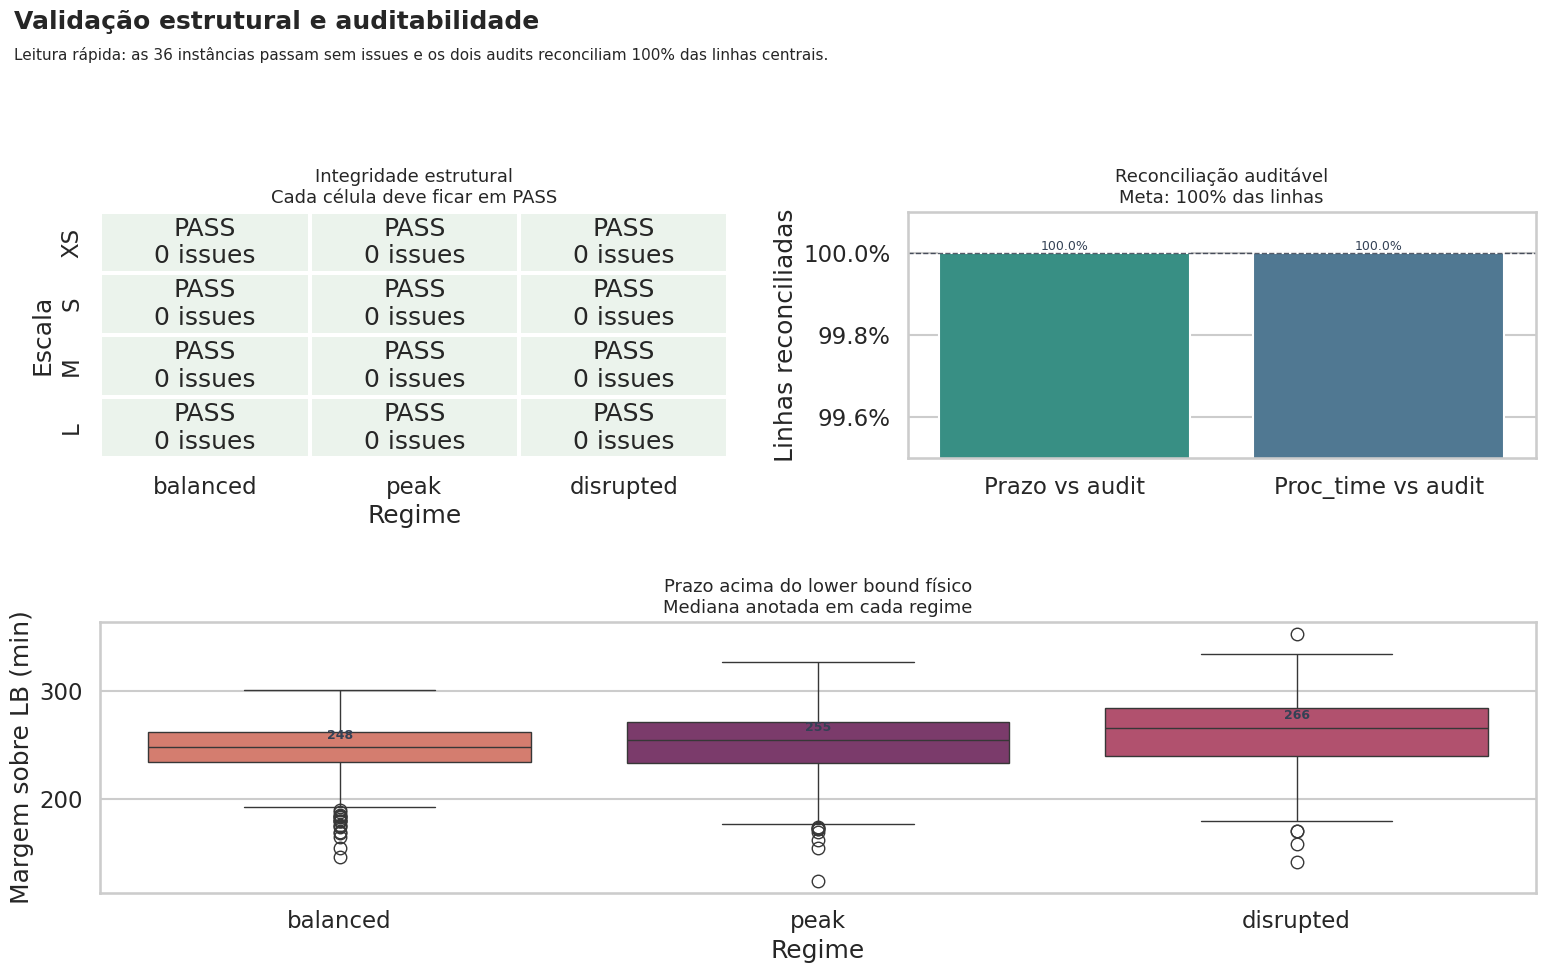

In [6]:
# The shared REPL backend already ships these reports with scale/regime context.

display(structural_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(fifo_schema_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(event_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(audit_reconciliation.sort_values(["scale_code", "regime_code", "instance_id"]))

due_margin_summary = (
    jobs_enriched.groupby(["scale_code", "regime_code"], as_index=False)[
        "due_margin_over_lb_min"
    ]
    .agg(["mean", "min", "median", "max"])
    .round(2)
    .reset_index()
)
display(due_margin_summary)

fig = repl.plot_validation_overview(ctx=NOTEBOOK_CTX, save=False)
plt.show()

structural_report.to_csv(ARTIFACT_DIR / "structural_report.csv", index=False)
fifo_schema_report.to_csv(ARTIFACT_DIR / "fifo_schema_report.csv", index=False)
event_report.to_csv(ARTIFACT_DIR / "event_report.csv", index=False)
audit_reconciliation.to_csv(ARTIFACT_DIR / "audit_reconciliation.csv", index=False)
due_margin_summary.to_csv(ARTIFACT_DIR / "due_margin_summary.csv", index=False)

**Como ler a figura acima**

- painel esquerdo: cada célula deve ficar em `PASS`; se aparecer número de issues, aquela família tem falhas estruturais
- a tabela `fifo_schema_report` formaliza a executabilidade do baseline FIFO: elegibilidade, `release_time`, precedência, overlap e downtime
- painel central: os dois bars precisam ficar em `100%`; qualquer queda indica quebra entre CSV central e CSV de audit
- painel direito: mostra quanta folga de prazo sobra acima do lower bound físico plausível

## Relational consistency across core files

A validação estrutural garante executabilidade, mas ainda vale explicitar se os
arquivos do release continuam coerentes entre si como estrutura relacional.
Aqui verificamos:

- cardinalidade `job -> 4 operações`
- cardinalidade `job -> 3 precedências`
- completude de elegibilidade por operação
- integridade referencial entre `schedule`, `machines`, `job_metrics` e `events`
- unicidade do mapeamento `operação -> linha do FIFO`

,check_name,pass_rate,failed_instance_count
0,every_operation_has_eligible_machine_ok,1.0,0
1,fifo_has_one_row_per_operation_ok,1.0,0
2,job_events_fk_ok,1.0,0
3,job_has_3_precedences_ok,1.0,0
4,job_has_4_operations_ok,1.0,0
5,machine_events_fk_ok,1.0,0
6,metrics_job_fk_ok,1.0,0
7,schedule_machine_fk_ok,1.0,0
8,schedule_operation_fk_ok,1.0,0


,instance_id,job_has_4_operations_ok,job_has_3_precedences_ok,every_operation_has_eligible_machine_ok,fifo_has_one_row_per_operation_ok,schedule_operation_fk_ok,schedule_machine_fk_ok,metrics_job_fk_ok,job_events_fk_ok,machine_events_fk_ok,job_with_wrong_op_count,job_with_wrong_prec_count,operations_without_eligible_machine,operations_without_single_schedule_row,metrics_job_count_gap,scale_code,regime_code
0,GO_L_BALANCED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
7,GO_L_PEAK_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
8,GO_L_PEAK_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
9,GO_M_BALANCED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,M,balanced


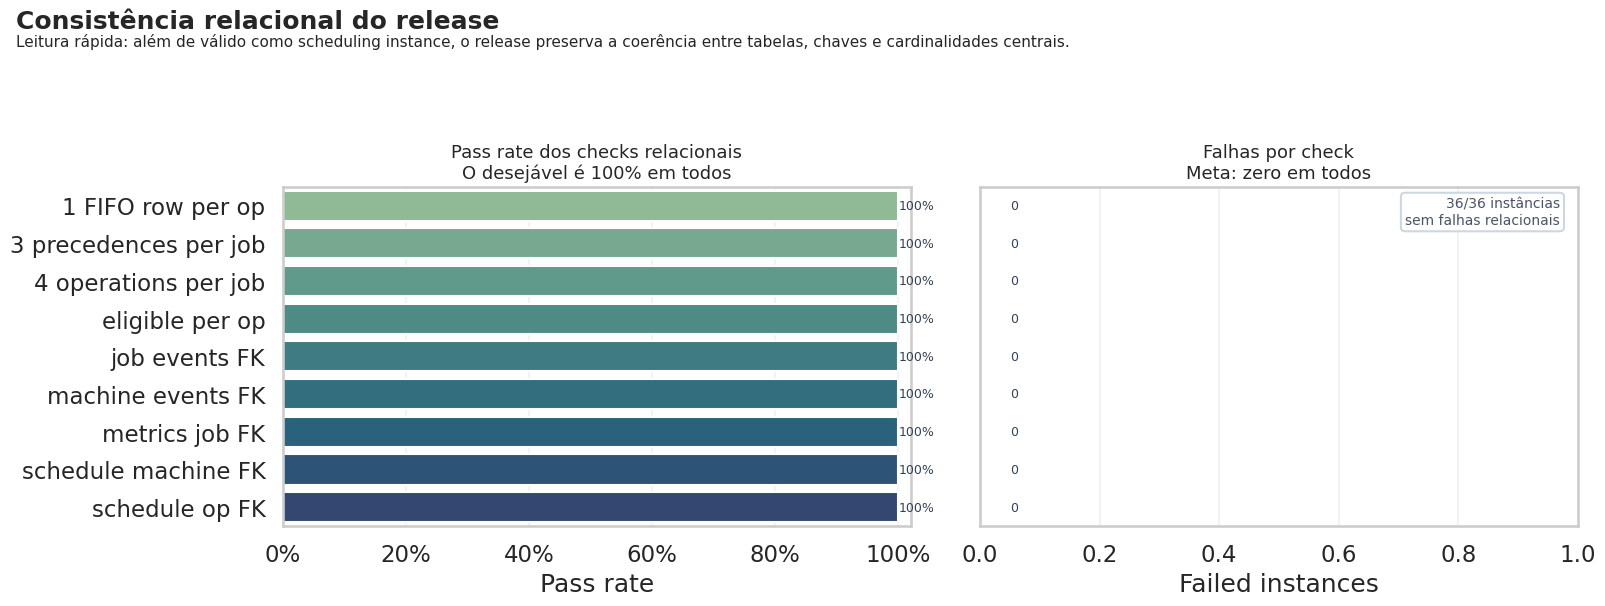

In [7]:
relational_consistency_report, relational_consistency_summary = paper.build_relational_consistency_reports(
    jobs=jobs,
    operations=operations,
    precedences=precedences,
    eligible=eligible,
    machines=machines,
    events=events,
    schedule=schedule,
    job_metrics=job_metrics,
    params=params,
)
display(relational_consistency_summary)
display(relational_consistency_report.sort_values(["scale_code", "regime_code", "instance_id"]))

relational_label_map = {
    "every_operation_has_eligible_machine_ok": "eligible per op",
    "fifo_has_one_row_per_operation_ok": "1 FIFO row per op",
    "job_has_3_precedences_ok": "3 precedences per job",
    "job_has_4_operations_ok": "4 operations per job",
    "job_events_fk_ok": "job events FK",
    "machine_events_fk_ok": "machine events FK",
    "metrics_job_fk_ok": "metrics job FK",
    "schedule_machine_fk_ok": "schedule machine FK",
    "schedule_operation_fk_ok": "schedule op FK",
}
relational_plot = relational_consistency_summary.copy()
relational_plot["check_label"] = relational_plot["check_name"].map(relational_label_map).fillna(relational_plot["check_name"])
relational_plot = relational_plot.sort_values(["failed_instance_count", "check_label"], ascending=[False, True])

fig, axes = plt.subplot_mosaic([["rate", "failures"]], figsize=(16, 5.2))
sns.barplot(
    data=relational_plot,
    x="pass_rate",
    y="check_label",
    ax=axes["rate"],
    color="#2a9d8f",
)
axes["rate"].set_title("Consistência relacional: taxa de aprovação por check")
axes["rate"].set_xlabel("pass_rate")
axes["rate"].set_ylabel("check")
axes["rate"].set_xlim(0, 1.02)

sns.barplot(
    data=relational_plot,
    x="failed_instance_count",
    y="check_label",
    ax=axes["failures"],
    color="#e76f51",
)
axes["failures"].set_title("Instâncias com falha por check relacional")
axes["failures"].set_xlabel("failed_instance_count")
axes["failures"].set_ylabel("")
fig.tight_layout()
plt.show()
plt.close(fig)

relational_consistency_report.to_csv(ARTIFACT_DIR / "relational_consistency_report.csv", index=False)
relational_consistency_summary.to_csv(ARTIFACT_DIR / "relational_consistency_summary.csv", index=False)


**Como ler a figura acima**

- o painel esquerdo mostra a taxa de aprovação dos checks relacionais; para publicação formal, o desejável é `100%`
- o painel direito mostra quantas instâncias falham em cada check; o desejável é `0`
- esta seção complementa a integridade estrutural: ela mostra que os arquivos do release não estão apenas “bem formatados”, mas também coerentes como sistema relacional


## Observational layer behavior

Esta seção testa se a camada observacional cumpriu seu papel:

- a prioridade continua importante, mas não perfeitamente determinística
- tempos de `UNLOAD` continuam interpretáveis por carga, máquina, umidade e congestionamento
- o ruído aparece de forma estruturada, e não como barulho arbitrário

,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture
0,0.4848,0.4995


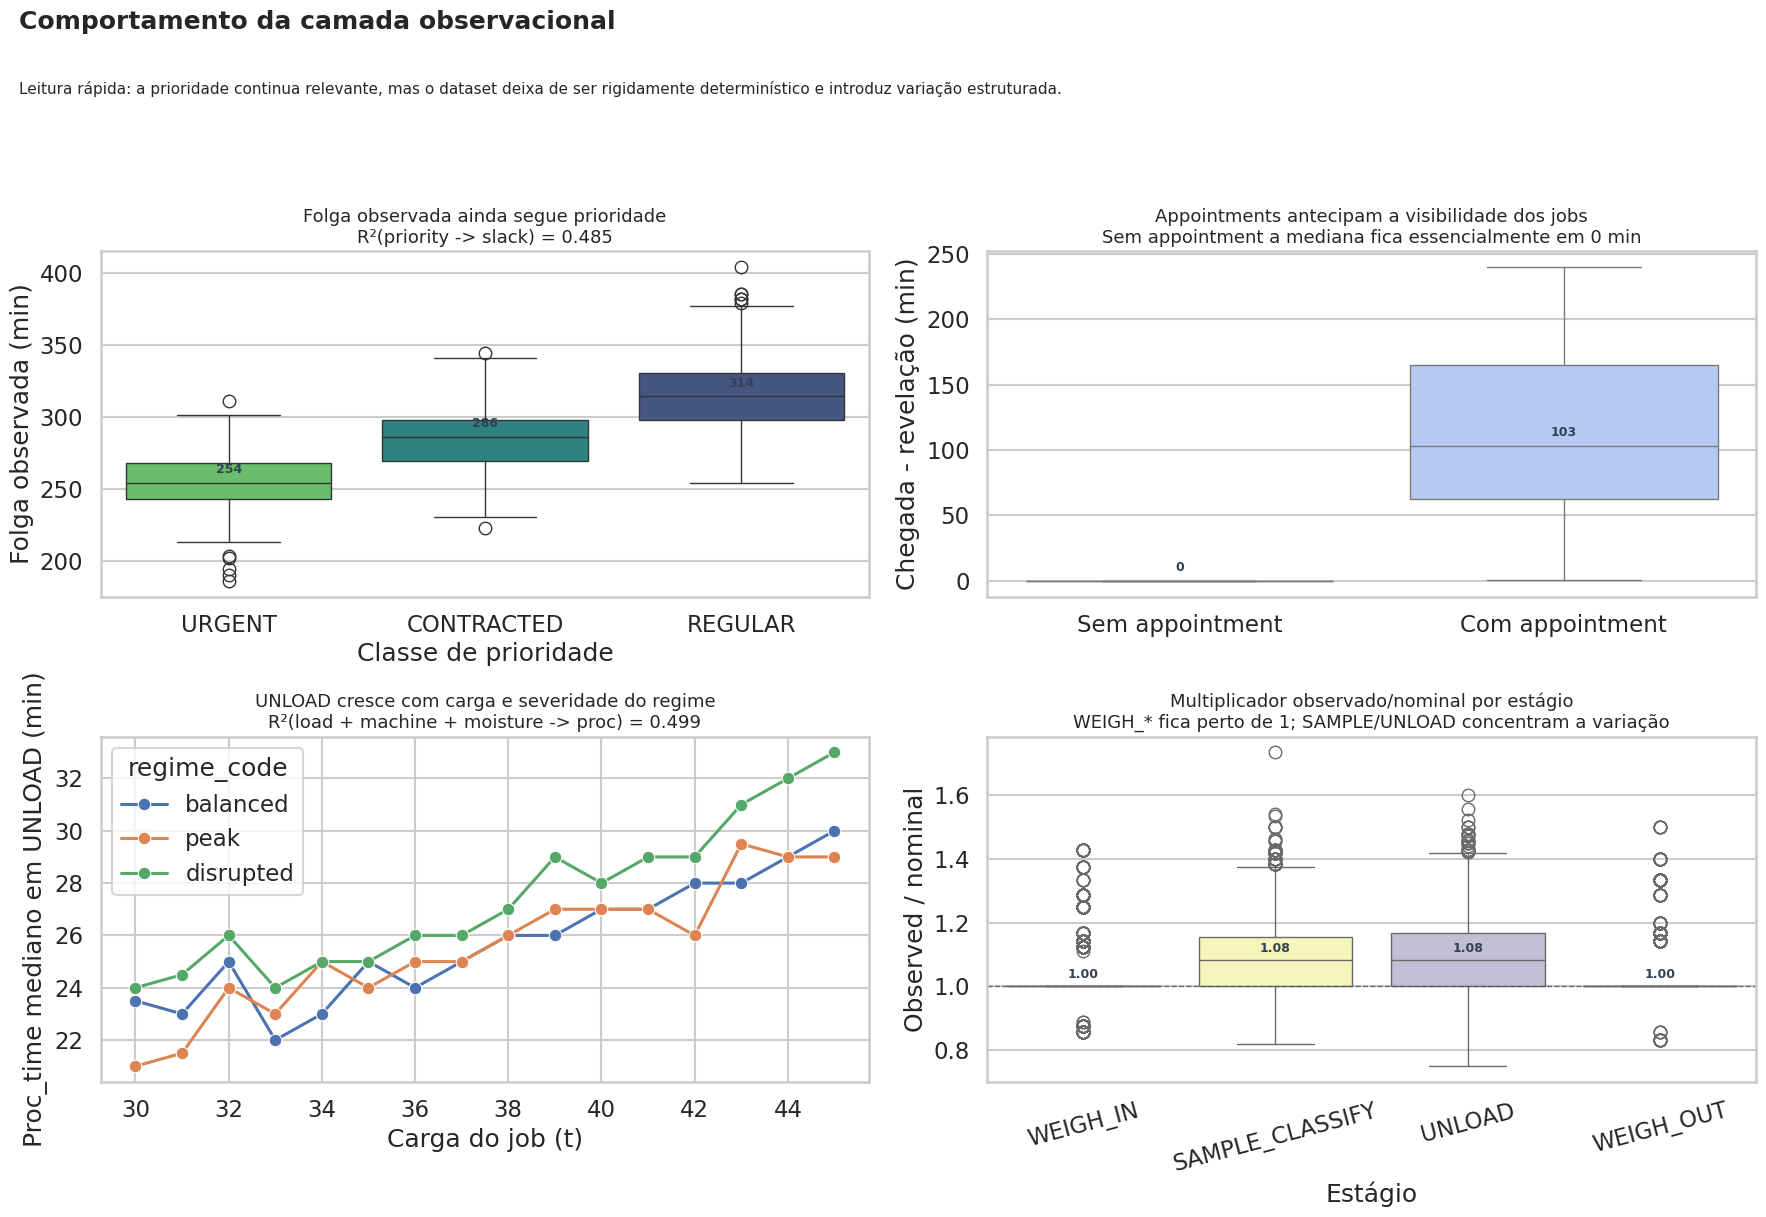

In [8]:
diagnostics_df = pd.DataFrame([diagnostics])
display(diagnostics_df)

fig = repl.plot_observational_layer(ctx=NOTEBOOK_CTX, save=False)
plt.show()

**Como ler a figura acima**

- prioridade ainda ordena a folga de prazo, mas o `R²` abaixo de `0.5` mostra que ela não explica tudo sozinha
- `appointment` afeta visibilidade antes da chegada, o que ajuda a aproximar o benchmark de uma operação real
- em `UNLOAD`, a carga e o regime empurram o tempo mediano para cima
- os multiplicadores por estágio mostram onde a camada observacional realmente introduziu variação

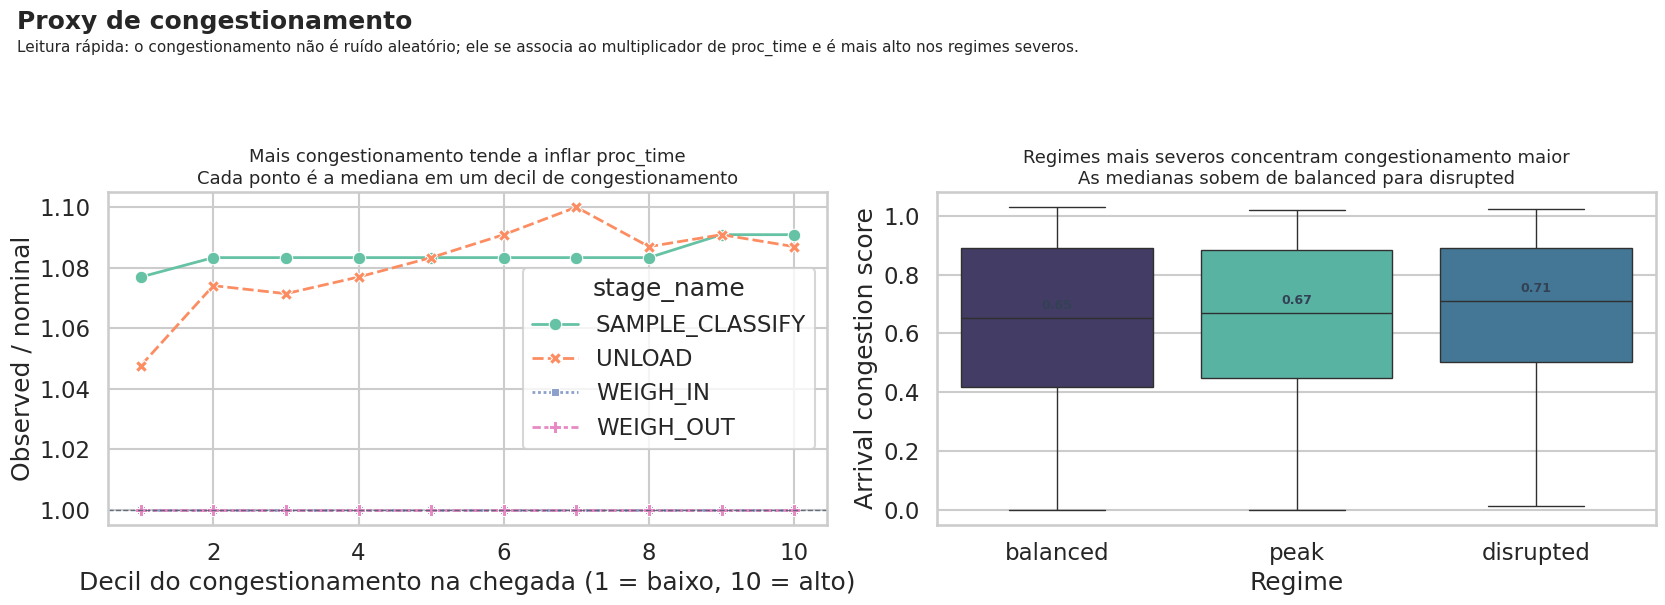

In [9]:
fig = repl.plot_congestion_diagnostics(ctx=NOTEBOOK_CTX, save=False)
plt.show()

**Como ler a figura acima**

- no painel esquerdo, cada linha resume um estágio por decil de congestionamento; inclinação positiva significa que o proxy está influenciando `proc_time`
- no painel direito, `balanced`, `peak` e `disrupted` deveriam deslocar a distribuição para cima nessa ordem

## Formal two-sample tests for the observational layer

Os gráficos anteriores mostram a camada observacional de forma intuitiva. Aqui,
adicionamos testes formais inspirados na literatura de avaliação de dados
sintéticos, mas adaptados ao que é viável com os artefatos já presentes no repo.

Como não temos um `holdout real` dentro deste repositório, os testes abaixo medem
o deslocamento entre a visão `nominal` e a visão `observada` do mesmo benchmark.
Eles ajudam a responder se a transformação introduziu mudança detectável, porém
ainda estruturada e semanticamente legível.

,experiment,rows_per_domain,feature_count,c2st_auc_mean,c2st_auc_std,c2st_auc_oof,mmd_rbf_stat,mmd_permutation_pvalue
0,job_due_layer,1848,22,0.777706,0.013218,0.777503,0.005687,0.012346
1,proc_time_layer,4000,23,0.597995,0.024802,0.597218,0.000980,0.765432


,regime_code,priority_class,sample_count_observed,mean_prob_observed_observed,mean_log_density_ratio_observed,sample_count_nominal,mean_prob_observed_nominal,mean_log_density_ratio_nominal,mean_prob_observed_delta,mean_log_density_ratio_delta,experiment
0,balanced,CONTRACTED,74,0.500958,0.020130,74,0.492433,-0.030241,0.008525,0.050371,job_due_layer
1,balanced,REGULAR,405,0.513417,0.065761,405,0.491647,-0.035532,0.021770,0.101293,job_due_layer
2,balanced,URGENT,25,0.398265,-0.564030,25,0.542412,0.173959,-0.144147,-0.737989,job_due_layer
3,disrupted,CONTRACTED,106,0.696375,1.130970,106,0.290461,-0.938352,0.405914,2.069322,job_due_layer
4,disrupted,REGULAR,443,0.736101,1.456798,443,0.266740,-1.048640,0.469362,2.505438,job_due_layer
5,disrupted,URGENT,123,0.687355,1.088060,123,0.320044,-0.777173,0.367312,1.865233,job_due_layer
6,peak,CONTRACTED,121,0.625581,0.709534,121,0.388203,-0.476974,0.237378,1.186508,job_due_layer
7,peak,REGULAR,474,0.612732,0.626407,474,0.385511,-0.491194,0.227221,1.117601,job_due_layer
8,peak,URGENT,77,0.587862,0.420509,77,0.414732,-0.357115,0.173130,0.777624,job_due_layer


,regime_code,stage_name,sample_count_observed,mean_prob_observed_observed,mean_log_density_ratio_observed,sample_count_nominal,mean_prob_observed_nominal,mean_log_density_ratio_nominal,mean_prob_observed_delta,mean_log_density_ratio_delta,experiment
0,balanced,SAMPLE_CLASSIFY,228,0.498368,-0.006509,219,0.467725,-0.131008,0.030642,0.124500,proc_time_layer
1,balanced,UNLOAD,293,0.546249,0.217511,268,0.489478,-0.040345,0.056771,0.257857,proc_time_layer
2,balanced,WEIGH_IN,313,0.515925,0.064363,297,0.511195,0.044805,0.004730,0.019558,proc_time_layer
3,balanced,WEIGH_OUT,311,0.529258,0.118093,303,0.526705,0.107888,0.002553,0.010204,proc_time_layer
4,disrupted,SAMPLE_CLASSIFY,261,0.541554,0.173043,294,0.458869,-0.168036,0.082685,0.341079,proc_time_layer
5,disrupted,UNLOAD,374,0.569131,0.336639,357,0.469746,-0.124592,0.099386,0.461231,proc_time_layer
6,disrupted,WEIGH_IN,388,0.498827,-0.005181,399,0.480141,-0.080742,0.018686,0.075561,proc_time_layer
7,disrupted,WEIGH_OUT,406,0.503561,0.014202,365,0.500732,0.002890,0.002828,0.011312,proc_time_layer
8,peak,SAMPLE_CLASSIFY,282,0.489760,-0.041113,301,0.463310,-0.149109,0.026450,0.107997,proc_time_layer
9,peak,UNLOAD,377,0.521404,0.106350,394,0.451103,-0.206452,0.070302,0.312802,proc_time_layer


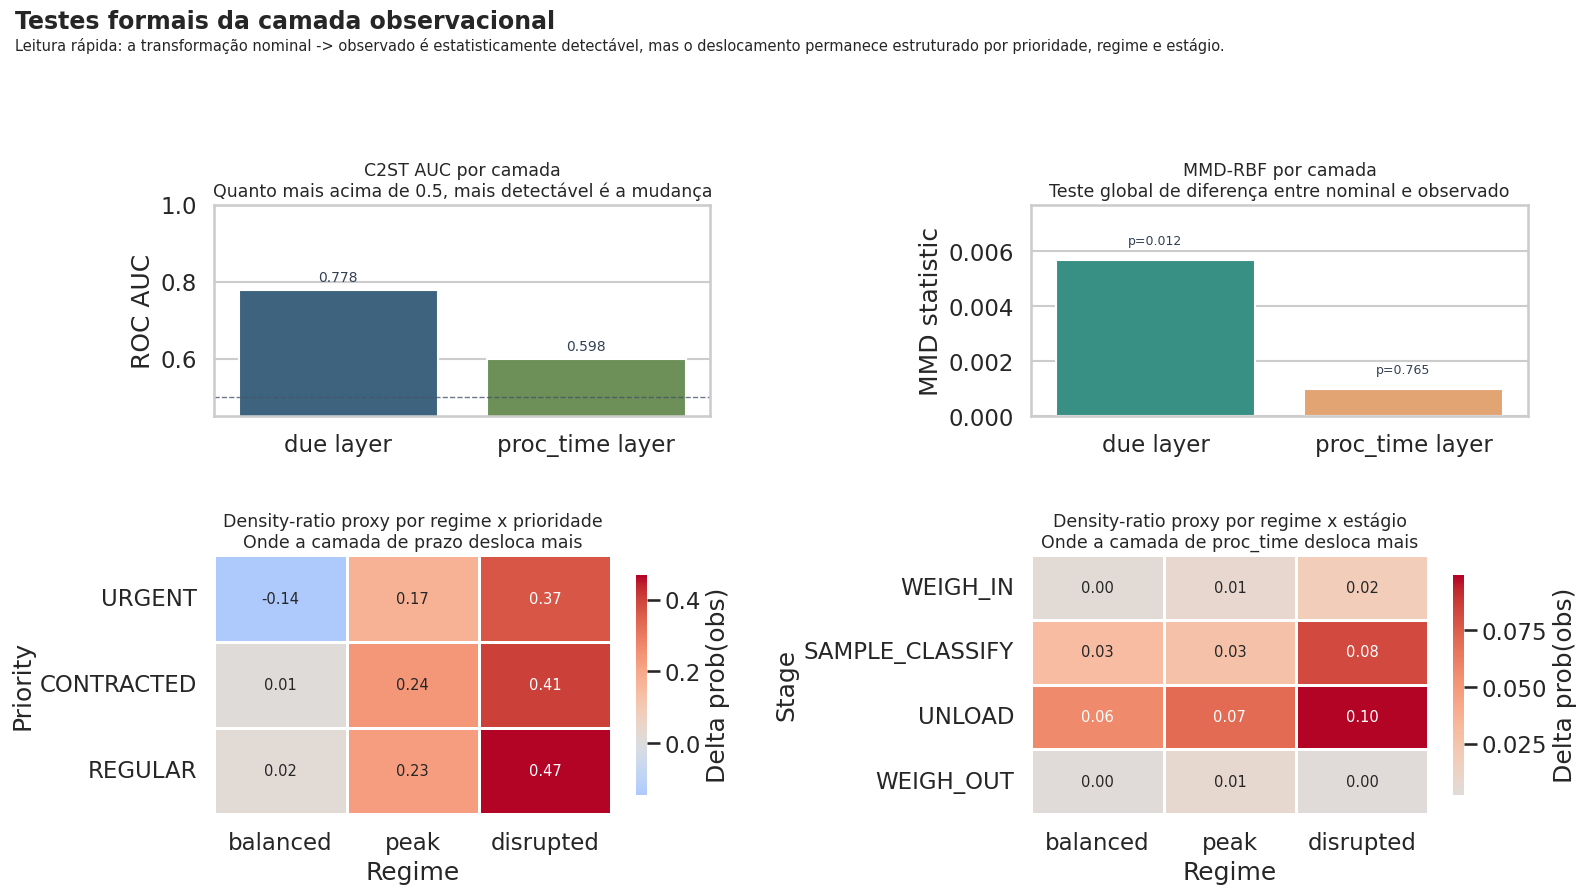

In [10]:
job_domain_base = (
    due_audit.merge(
        jobs[
            [
                "instance_id",
                "job_id",
                "load_tons",
                "priority_class",
                "appointment_flag",
                "moisture_class",
            ]
        ],
        on=["instance_id", "job_id"],
        how="left",
    )
)
job_domain_nominal = job_domain_base.assign(due_slack_min=job_domain_base["due_slack_nominal_min"])
job_domain_observed = job_domain_base.assign(due_slack_min=job_domain_base["due_slack_observed_min"])

proc_domain_base = proc_audit.copy()
proc_domain_nominal = proc_domain_base.assign(proc_time_min=proc_domain_base["proc_time_nominal_min"])
proc_domain_observed = proc_domain_base.assign(proc_time_min=proc_domain_base["proc_time_observed_min"])

job_shift_summary, job_density_segments = paper.run_domain_shift_experiment(
    nominal=job_domain_nominal,
    observed=job_domain_observed,
    numeric_cols=["arrival_time_min", "load_tons", "due_slack_min", "nominal_processing_lb_min"],
    categorical_cols=["priority_class", "appointment_flag", "moisture_class", "shift_bucket", "scale_code", "regime_code"],
    group_cols=["regime_code", "priority_class", "moisture_class"],
    label="job_due_layer",
    max_rows_per_domain=2400,
    mmd_sample_cap=600,
)
proc_shift_summary, proc_density_segments = paper.run_domain_shift_experiment(
    nominal=proc_domain_nominal,
    observed=proc_domain_observed,
    numeric_cols=["proc_time_min"],
    categorical_cols=["stage_name", "machine_id", "shift_bucket", "scale_code", "regime_code", "moisture_class"],
    group_cols=["stage_name", "machine_id"],
    label="proc_time_layer",
    max_rows_per_domain=3200,
    mmd_sample_cap=700,
)

formal_shift_summary = pd.concat([job_shift_summary, proc_shift_summary], ignore_index=True)
display(formal_shift_summary)
display(job_density_segments.head(12))
display(proc_density_segments.head(12))

fig, axes = plt.subplot_mosaic([["auc", "mmd"], ["job_density", "proc_density"]], figsize=(16.5, 11.5))

sns.barplot(data=formal_shift_summary, x="experiment", y="c2st_auc_mean", ax=axes["auc"], color="#457b9d")
axes["auc"].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes["auc"].set_ylim(0.0, 1.0)
axes["auc"].set_title("C2ST AUC médio por experimento")
axes["auc"].set_ylabel("AUC")
axes["auc"].set_xlabel("")

sns.barplot(data=formal_shift_summary, x="experiment", y="mmd_rbf_stat", ax=axes["mmd"], color="#e76f51")
axes["mmd"].set_title("MMD-RBF por experimento")
axes["mmd"].set_ylabel("MMD")
axes["mmd"].set_xlabel("")

job_density_plot = job_density_segments.sort_values("mean_log_density_ratio_delta", ascending=False).head(14)
sns.barplot(
    data=job_density_plot,
    x="mean_log_density_ratio_delta",
    y="priority_class",
    hue="moisture_class",
    ax=axes["job_density"],
)
axes["job_density"].set_title("Density ratio proxy: segmentos de prazo")
axes["job_density"].set_xlabel("delta log-density")
axes["job_density"].set_ylabel("priority_class")

proc_density_plot = proc_density_segments.copy()
proc_density_plot["stage_machine"] = proc_density_plot["stage_name"] + " | " + proc_density_plot["machine_id"]
proc_density_plot = proc_density_plot.sort_values("mean_log_density_ratio_delta", ascending=False).head(14)
sns.barplot(
    data=proc_density_plot,
    x="mean_log_density_ratio_delta",
    y="stage_machine",
    ax=axes["proc_density"],
    color="#2a9d8f",
)
axes["proc_density"].set_title("Density ratio proxy: segmentos de tempo de processamento")
axes["proc_density"].set_xlabel("delta log-density")
axes["proc_density"].set_ylabel("stage | machine")
fig.tight_layout()
plt.show()
plt.close(fig)

formal_shift_summary.to_csv(ARTIFACT_DIR / "formal_shift_experiments_summary.csv", index=False)
job_density_segments.to_csv(ARTIFACT_DIR / "job_density_ratio_segments.csv", index=False)
proc_density_segments.to_csv(ARTIFACT_DIR / "proc_density_ratio_segments.csv", index=False)


**Como ler a figura acima**

- `C2ST` mede o quão fácil é distinguir `nominal` de `observed`; valores acima de `0.5` indicam mudança detectável
- `MMD` mede a diferença global entre distribuições; `p-values` pequenos indicam que o deslocamento é estatisticamente real
- os heatmaps inferiores funcionam como um proxy de `density ratio`: eles mostram em quais combinações de `regime x prioridade` e `regime x estágio` a transformação ficou mais forte
- a leitura desejada não é “mudança zero”; é “mudança detectável e interpretável”, sem colapso semântico da estrutura original

## Operational performance and regime sanity

A validação não depende só de integridade estrutural. Também interessa saber se:

- `balanced < peak < disrupted` permanece verdadeiro para `mean_flow` e `p95_flow`
- a fila média também preserva monotonicidade
- o proxy médio de congestionamento não precisa ser monotônico em todas as famílias
- os tempos de fluxo e fila continuam coerentes com a escala do problema
- a utilização de recurso faz sentido por família de máquina

,scale_code,mean_flow_order_ok,p95_flow_order_ok,mean_queue_order_ok,mean_congestion_order_ok
0,L,True,True,True,True
1,M,True,True,True,False
2,S,True,True,True,True
3,XS,True,True,True,True


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


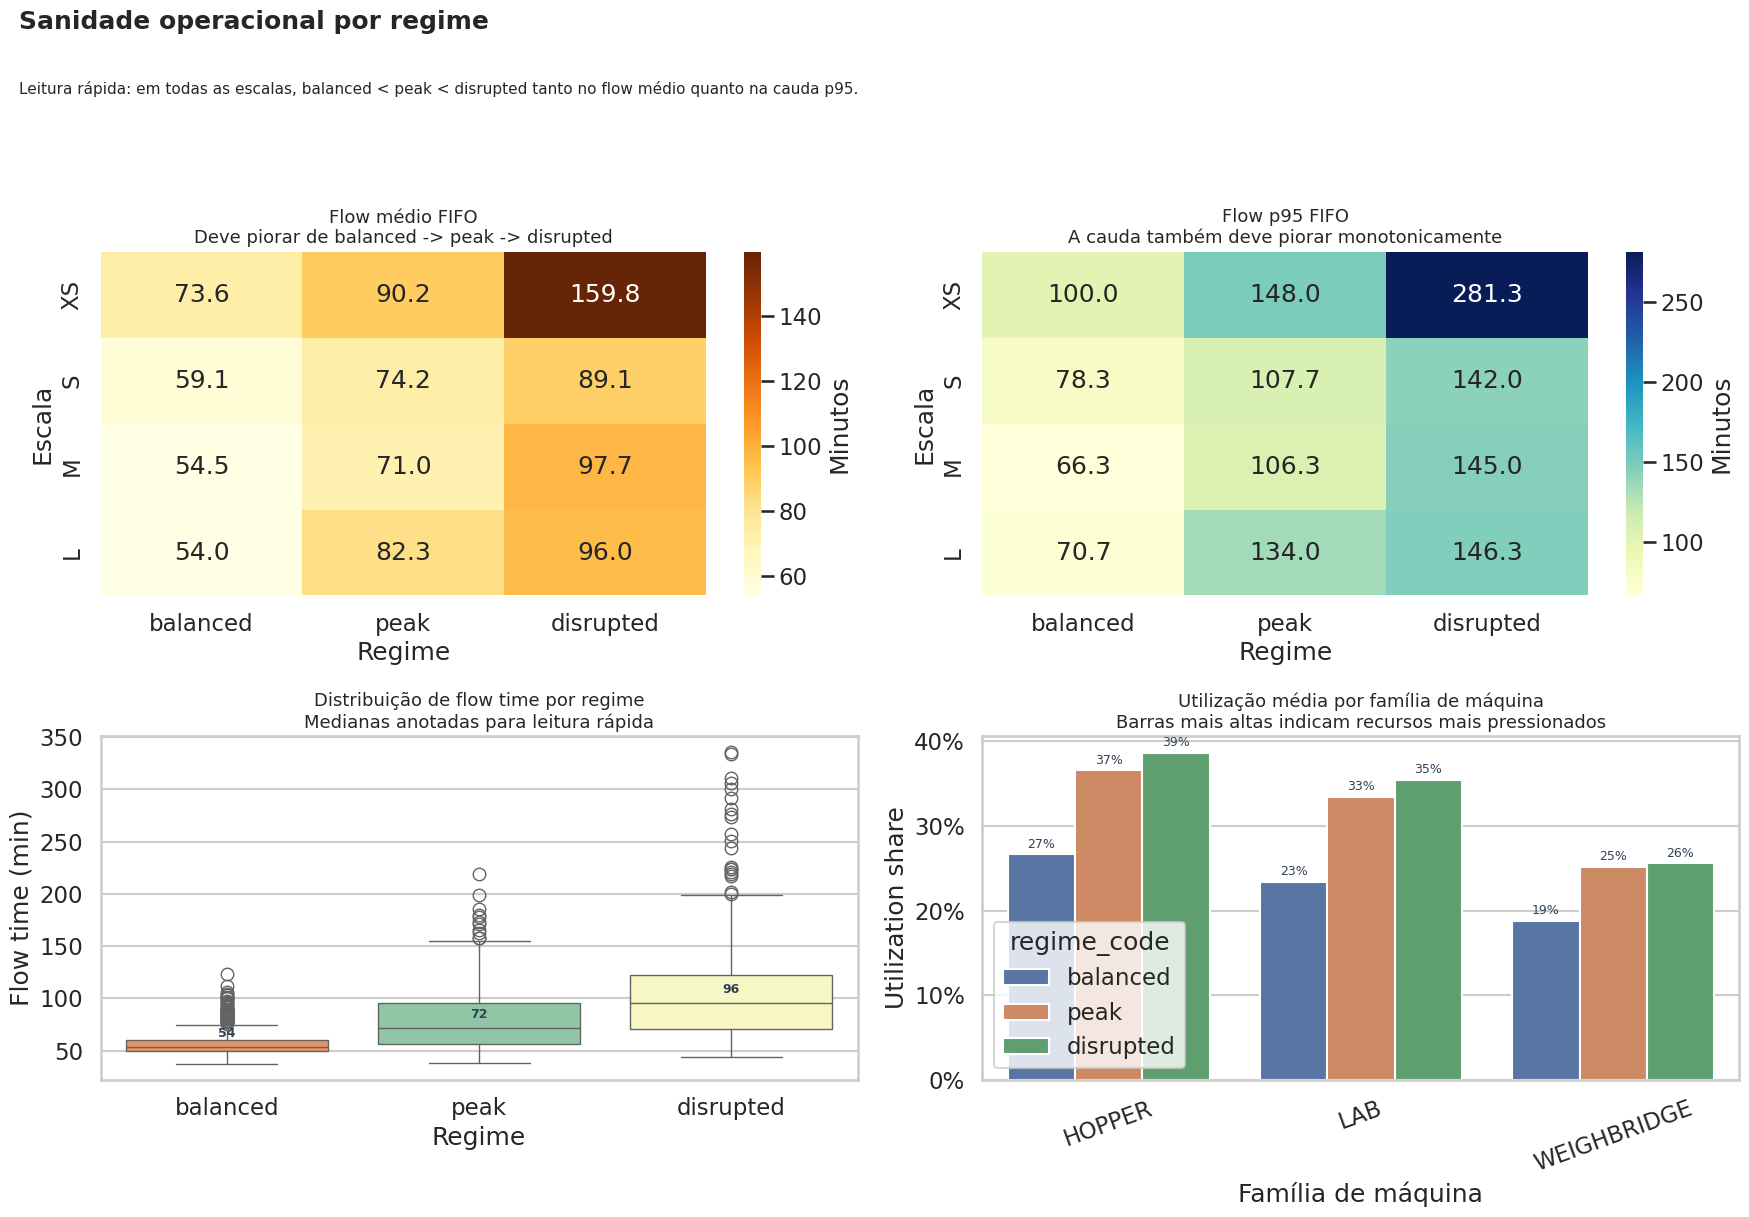

In [11]:
display(regime_checks)
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_operational_sanity(ctx=NOTEBOOK_CTX, save=False)
plt.show()

**Como ler a figura acima**

- os heatmaps do topo validam a monotonicidade esperada apenas para `flow`: `balanced < peak < disrupted`
- a tabela `regime_checks` separa formalmente os checks de `flow`, `queue` e `congestion`
- o boxplot inferior esquerdo mostra a distribuição de `flow_time` no nível de job
- o gráfico inferior direito ajuda a ver quais famílias de máquina absorvem mais pressão em cada regime

## Tail behavior and rare segments

Médias e medianas ajudam, mas não são suficientes para validar um benchmark
sintético operacional. Também interessa saber:

- se as caudas `p95/p99` continuam obedecendo o gradiente de regime
- se a margem sobre o lower bound continua plausível nos piores casos
- se segmentos raros, como `URGENT` e `WET`, permanecem operacionais e não colapsam em artefatos estranhos

,scale_code,regime_code,flow_p95,flow_p99,queue_p95,queue_p99,overwait_share,due_margin_p05
0,L,balanced,74.25,89.00,25.00,38.55,0.000000,210.25
1,L,disrupted,147.30,159.00,94.00,102.52,0.000000,195.00
2,L,peak,138.55,171.26,87.90,116.52,0.000000,205.35
3,M,balanced,67.85,71.85,13.70,24.57,0.000000,188.30
4,M,disrupted,151.25,163.18,97.00,108.18,0.000000,199.10
5,M,peak,116.45,127.18,57.35,70.00,0.000000,192.55
6,S,balanced,84.10,96.77,27.75,35.88,0.000000,187.60
7,S,disrupted,147.10,158.24,88.05,102.05,0.000000,198.90
8,S,peak,111.15,121.43,54.05,64.81,0.000000,190.90
9,XS,balanced,104.70,117.17,46.35,60.28,0.000000,196.25


,scale_code,flow_p99_order_ok,queue_p99_order_ok,due_margin_p05_order_ok
0,L,False,False,True
1,M,True,True,False
2,S,True,True,False
3,XS,True,True,False


,segment_label,job_count,job_share,flow_mean,flow_p95,queue_mean,queue_p95,overwait_share,due_margin_p05
0,WET,573,0.310065,89.951134,154.0,31.657941,92.4,0.001745,199.6
1,APPOINTMENT_AND_WET,361,0.195346,87.520776,151.0,29.620499,88.0,0.000000,193.0
2,URGENT,225,0.121753,85.506667,149.0,31.653333,97.0,0.004444,170.4
3,APPOINTMENT,1219,0.659632,79.863823,143.0,26.924528,88.0,0.002461,192.0
4,URGENT_AND_WET,75,0.040584,86.506667,141.3,28.013333,79.9,0.000000,169.7


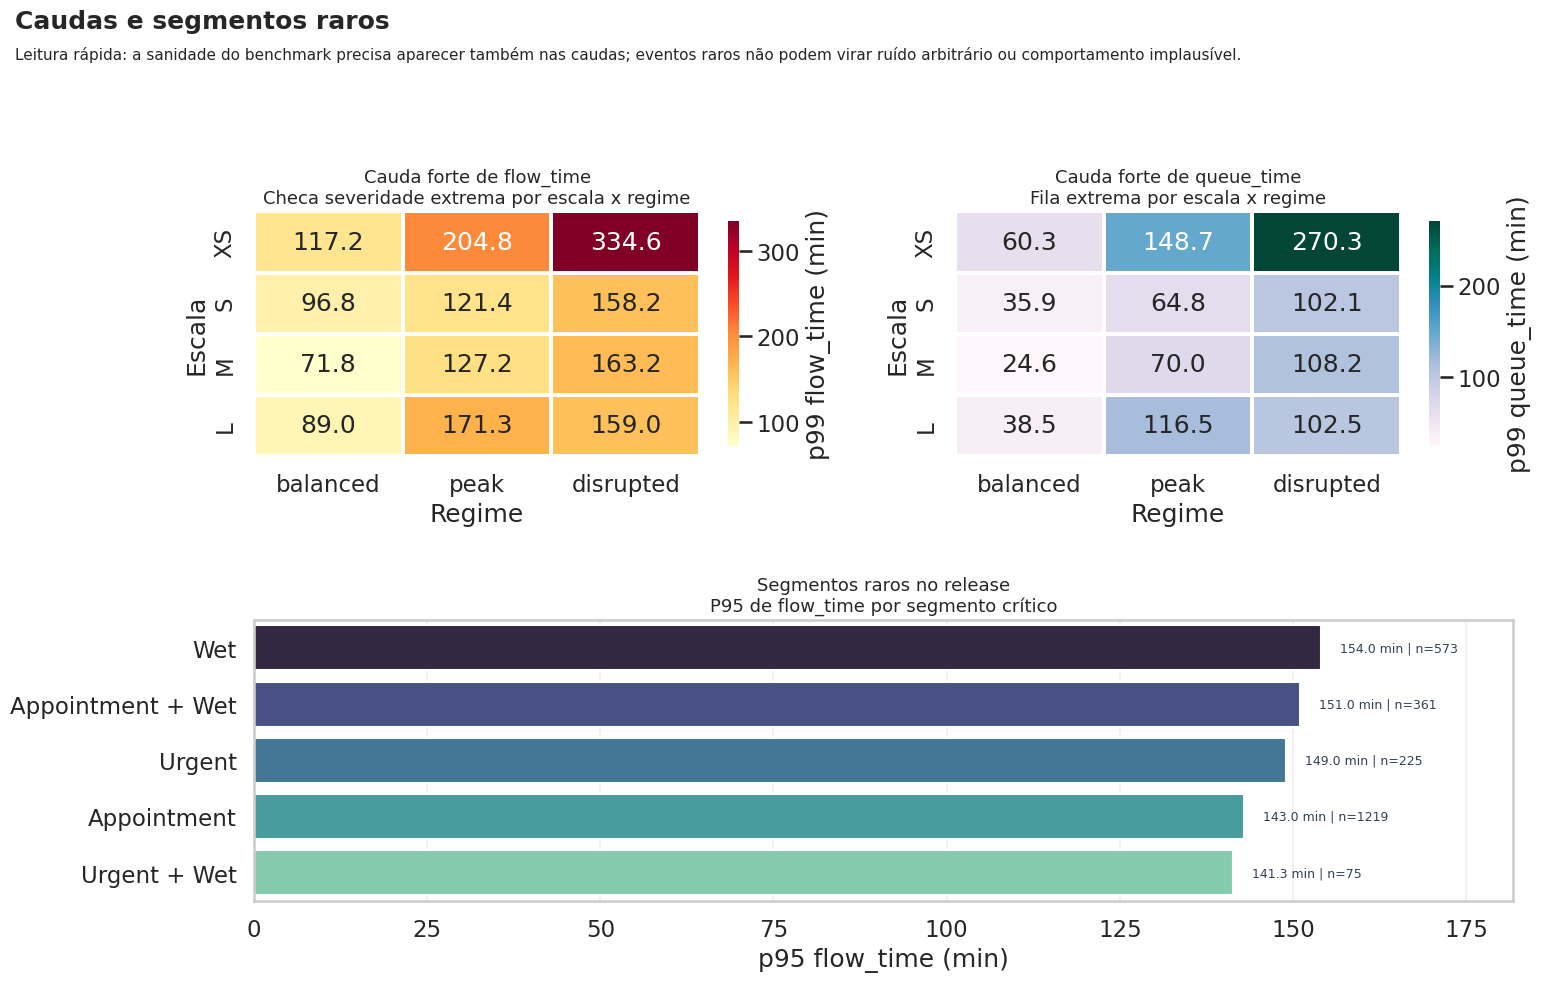

In [12]:
tail_regime_summary, tail_regime_checks, rare_segment_summary = paper.build_tail_and_segment_reports(
    jobs_enriched=jobs_enriched,
    job_metrics=job_metrics,
)
display(tail_regime_summary.sort_values(["scale_code", "regime_code"]))
display(tail_regime_checks.sort_values("scale_code"))
display(rare_segment_summary)

flow_p99_heatmap = (
    tail_regime_summary.pivot(index="scale_code", columns="regime_code", values="flow_p99")
    .reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
)
queue_p99_heatmap = (
    tail_regime_summary.pivot(index="scale_code", columns="regime_code", values="queue_p99")
    .reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
)
rare_segment_plot = rare_segment_summary.copy()
rare_segment_plot["segment_display"] = (
    rare_segment_plot["segment_label"]
    .str.replace("_AND_", " + ", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)
rare_segment_plot = rare_segment_plot.sort_values("flow_p95", ascending=False).reset_index(drop=True)

fig, axes = plt.subplot_mosaic(
    [["flow", "queue"], ["rare", "rare"]],
    figsize=(15.8, 10.1),
    gridspec_kw={"height_ratios": [1.0, 1.15]},
)
sns.heatmap(
    flow_p99_heatmap,
    annot=True,
    fmt=".1f",
    cmap="mako",
    ax=axes["flow"],
    cbar_kws={"label": "flow_p99 (min)"},
)
axes["flow"].set_title("Cauda de flow time: p99 por escala × regime")

sns.heatmap(
    queue_p99_heatmap,
    annot=True,
    fmt=".1f",
    cmap="crest",
    ax=axes["queue"],
    cbar_kws={"label": "queue_p99 (min)"},
)
axes["queue"].set_title("Cauda de fila: p99 por escala × regime")

sns.barplot(
    data=rare_segment_plot,
    x="flow_p95",
    y="segment_display",
    color="#e76f51",
    ax=axes["rare"],
)
axes["rare"].set_title("Segmentos raros: flow_p95")
axes["rare"].set_xlabel("flow_p95 (min)")
axes["rare"].set_ylabel("segmento")
fig.tight_layout()
plt.show()
plt.close(fig)

tail_regime_summary.to_csv(ARTIFACT_DIR / "tail_regime_summary.csv", index=False)
tail_regime_checks.to_csv(ARTIFACT_DIR / "tail_regime_checks.csv", index=False)
rare_segment_summary.to_csv(ARTIFACT_DIR / "rare_segment_summary.csv", index=False)


**Como ler a figura acima**

- os dois heatmaps verificam se o gradiente `balanced < peak < disrupted` continua aparecendo também nas caudas `p99`
- a tabela `tail_regime_checks` formaliza essa monotonicidade forte por escala
- o gráfico de segmentos raros ajuda a ver se classes menos frequentes, como `URGENT` e `WET`, preservam comportamento plausível em `flow_time`
- esta seção é importante porque benchmarks sintéticos costumam acertar médias e errar justamente os eventos extremos

## Instance-space coverage and redundancy screening

Além de ser íntegro e executável, o release precisa cobrir regiões distintas do problema.
Para dados sintéticos, isso é crucial: um benchmark só é realmente útil se não colapsar
em um conjunto de instâncias quase idênticas.

Nesta seção, `PCA` e `kNN` cumprem papéis complementares:

- `PCA` testa a cobertura global do espaço de instâncias; ele ajuda a ver se as instâncias ocupam regiões diferentes do problema ou se estão comprimidas em um bloco estreito
- `kNN` testa a redundância local; mesmo quando a projeção em 2D parece boa, as distâncias de vizinhança mostram se há casos quase duplicados
- juntos, eles sustentam uma afirmação metodológica importante para o TCC: o dataset sintético não é apenas válido estruturalmente, mas também suficientemente diverso para funcionar como benchmark

Esta seção responde:

- se há duplicatas exatas no nível de instância
- se há casos "duplicate-like" em um espaço multivariado de features estruturais e operacionais
- quão dispersas as instâncias estão quando projetadas em 2D via PCA
- como as distâncias `kNN` evoluem para `k = 1, 3, 5`
- quão "pura" é a vizinhança em termos de regime e escala
- quais pares são os mais próximos dentro do release

,instance_count,feature_count,pca_pc1_explained_variance_ratio,pca_pc2_explained_variance_ratio,pca_pc1_pc2_explained_variance_ratio,exact_core_duplicate_count,exact_feature_duplicate_count,duplicate_like_threshold,duplicate_like_candidate_count,nearest_neighbor_distance_min,nearest_neighbor_distance_median,nearest_neighbor_distance_max,knn_same_regime_share_k5_mean,knn_same_scale_share_k5_mean
0,36,37,0.332119,0.257029,0.589148,0,0,2.0,0,2.322821,3.569669,6.170144,0.666667,0.683333


,instance_id,scale_code,regime_code,nearest_neighbor_instance_id,nearest_neighbor_distance,duplicate_like_candidate
6,GO_L_PEAK_01,L,peak,GO_L_PEAK_03,2.322821,False
8,GO_L_PEAK_03,L,peak,GO_L_PEAK_01,2.322821,False
5,GO_L_DISRUPTED_03,L,disrupted,GO_L_DISRUPTED_01,2.336918,False
3,GO_L_DISRUPTED_01,L,disrupted,GO_L_DISRUPTED_03,2.336918,False
9,GO_M_BALANCED_01,M,balanced,GO_M_BALANCED_02,2.632649,False
10,GO_M_BALANCED_02,M,balanced,GO_M_BALANCED_01,2.632649,False
7,GO_L_PEAK_02,L,peak,GO_L_PEAK_03,2.754415,False
16,GO_M_PEAK_02,M,peak,GO_M_BALANCED_02,2.766558,False
1,GO_L_BALANCED_02,L,balanced,GO_L_BALANCED_01,2.900777,False
0,GO_L_BALANCED_01,L,balanced,GO_L_BALANCED_02,2.900777,False


,instance_id,scale_code,regime_code,k,mean_knn_distance,max_knn_distance,same_regime_neighbor_share,same_scale_neighbor_share
18,GO_L_PEAK_01,L,peak,1,2.322821,2.322821,1.0,1.0
24,GO_L_PEAK_03,L,peak,1,2.322821,2.322821,1.0,1.0
9,GO_L_DISRUPTED_01,L,disrupted,1,2.336918,2.336918,1.0,1.0
15,GO_L_DISRUPTED_03,L,disrupted,1,2.336918,2.336918,1.0,1.0
27,GO_M_BALANCED_01,M,balanced,1,2.632649,2.632649,1.0,1.0
...,...,...,...,...,...,...,...,...
92,GO_XS_DISRUPTED_01,XS,disrupted,5,6.478725,7.242154,1.0,0.4
107,GO_XS_PEAK_03,XS,peak,5,6.493480,6.794259,0.6,0.6
104,GO_XS_PEAK_02,XS,peak,5,6.835401,7.129260,0.4,0.2
95,GO_XS_DISRUPTED_02,XS,disrupted,5,7.059355,8.017396,0.6,0.8


,source_regime,neighbor_regime,k,share
0,balanced,balanced,5,0.716667
1,balanced,disrupted,5,0.000000
2,balanced,peak,5,0.283333
3,disrupted,balanced,5,0.016667
4,disrupted,disrupted,5,0.766667
5,disrupted,peak,5,0.216667
6,peak,balanced,5,0.316667
7,peak,disrupted,5,0.166667
8,peak,peak,5,0.516667


,instance_a,instance_b,scale_a,scale_b,regime_a,regime_b,distance,duplicate_like_under_threshold
0,GO_L_PEAK_01,GO_L_PEAK_03,L,L,peak,peak,2.322821,False
1,GO_L_DISRUPTED_01,GO_L_DISRUPTED_03,L,L,disrupted,disrupted,2.336918,False
2,GO_M_BALANCED_01,GO_M_BALANCED_02,M,M,balanced,balanced,2.632649,False
3,GO_L_PEAK_02,GO_L_PEAK_03,L,L,peak,peak,2.754415,False
4,GO_M_BALANCED_02,GO_M_PEAK_02,M,M,balanced,peak,2.766558,False
5,GO_L_BALANCED_01,GO_L_BALANCED_02,L,L,balanced,balanced,2.900777,False
6,GO_L_DISRUPTED_02,GO_L_DISRUPTED_03,L,L,disrupted,disrupted,3.016497,False
7,GO_L_PEAK_01,GO_L_PEAK_02,L,L,peak,peak,3.172021,False
8,GO_M_BALANCED_03,GO_M_PEAK_02,M,M,balanced,peak,3.205998,False
9,GO_L_DISRUPTED_01,GO_L_DISRUPTED_02,L,L,disrupted,disrupted,3.364756,False


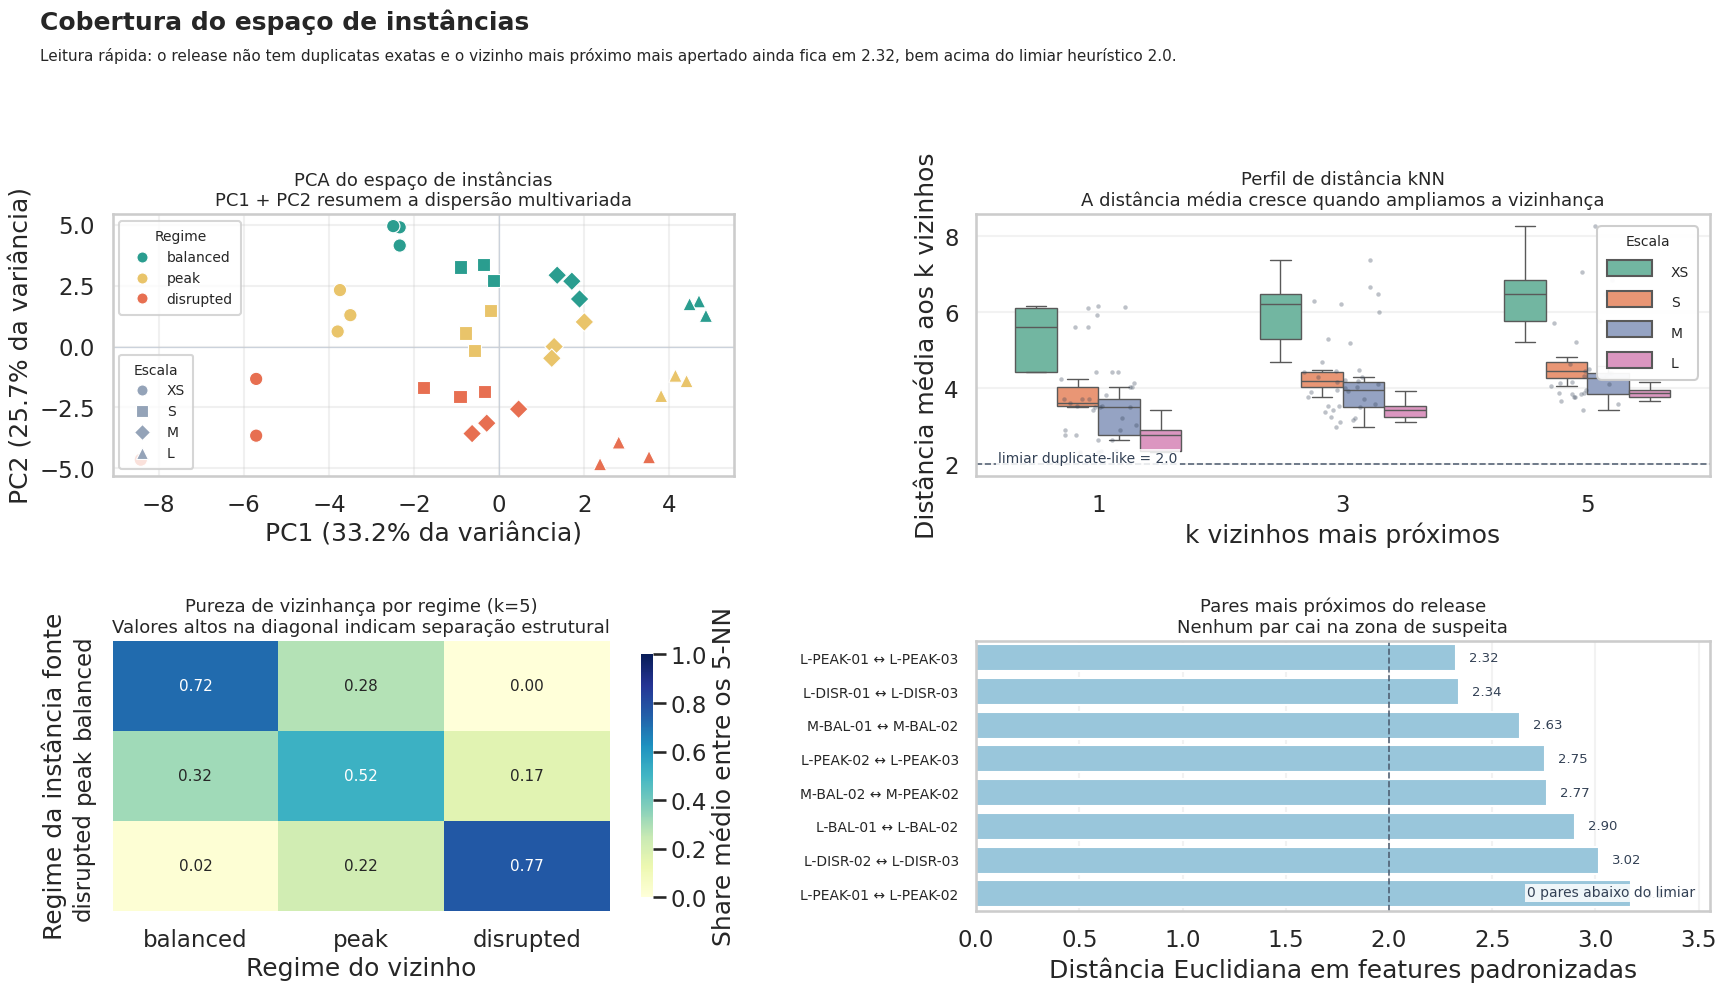


**Por que `PCA` e `kNN` importam para validar dados sintéticos**

- `PCA` fornece uma leitura **global** da cobertura do benchmark. Se todas as instâncias colapsassem na mesma região, o release seria pouco informativo para avaliação algorítmica.
- `kNN` fornece uma leitura **local** de redundância. Mesmo com boa separação visual em 2D, distâncias muito pequenas ainda denunciariam instâncias quase repetidas.
- Os dois testes se complementam: `PCA` responde se o release cobre regiões diferentes do problema, enquanto `kNN` responde se cada instância realmente acrescenta informação nova.
- Neste release, a evidência é favorável: `exact_core_duplicate_count = 0`, `exact_feature_duplicate_count = 0`, `duplicate_like_candidate_count = 0` e `nearest_neighbor_distance_min = 2.3228`.
- Em média, a vizinhança de `5-NN` preserva `same_regime_neighbor_share = 0.6667` e `same_scale_neighbor_share = 0.6833`, o que mostra estrutura sem colapso em duplicatas.


In [13]:
display(instance_space_summary)
display(
    instance_space_features[
        [
            "instance_id",
            "scale_code",
            "regime_code",
            "nearest_neighbor_instance_id",
            "nearest_neighbor_distance",
            "duplicate_like_candidate",
        ]
    ].sort_values("nearest_neighbor_distance")
)
display(instance_space_knn_profile.sort_values(["k", "mean_knn_distance", "instance_id"]))
display(instance_space_knn_regime_composition[instance_space_knn_regime_composition["k"] == 5])
display(instance_space_pairs.head(12))

fig = repl.plot_instance_space_coverage(ctx=NOTEBOOK_CTX, save=False)
plt.show()
plt.close(fig)

instance_space_note = f"""
**Por que `PCA` e `kNN` importam para validar dados sintéticos**

- `PCA` fornece uma leitura **global** da cobertura do benchmark. Se todas as instâncias colapsassem na mesma região, o release seria pouco informativo para avaliação algorítmica.
- `kNN` fornece uma leitura **local** de redundância. Mesmo com boa separação visual em 2D, distâncias muito pequenas ainda denunciariam instâncias quase repetidas.
- Os dois testes se complementam: `PCA` responde se o release cobre regiões diferentes do problema, enquanto `kNN` responde se cada instância realmente acrescenta informação nova.
- Neste release, a evidência é favorável: `exact_core_duplicate_count = {int(instance_space_summary.loc[0, "exact_core_duplicate_count"])}`, `exact_feature_duplicate_count = {int(instance_space_summary.loc[0, "exact_feature_duplicate_count"])}`, `duplicate_like_candidate_count = {int(instance_space_summary.loc[0, "duplicate_like_candidate_count"])}` e `nearest_neighbor_distance_min = {float(instance_space_summary.loc[0, "nearest_neighbor_distance_min"]):.4f}`.
- Em média, a vizinhança de `5-NN` preserva `same_regime_neighbor_share = {float(instance_space_summary.loc[0, "knn_same_regime_share_k5_mean"]):.4f}` e `same_scale_neighbor_share = {float(instance_space_summary.loc[0, "knn_same_scale_share_k5_mean"]):.4f}`, o que mostra estrutura sem colapso em duplicatas.
"""
display(Markdown(instance_space_note))

instance_space_features.to_csv(ARTIFACT_DIR / "instance_space_features.csv", index=False)
instance_space_pairs.to_csv(ARTIFACT_DIR / "instance_space_pairs.csv", index=False)
instance_space_summary.to_csv(ARTIFACT_DIR / "instance_space_summary.csv", index=False)
instance_space_knn_profile.to_csv(ARTIFACT_DIR / "instance_space_knn_profile.csv", index=False)
instance_space_knn_regime_composition.to_csv(ARTIFACT_DIR / "instance_space_knn_regime_composition.csv", index=False)
instance_space_knn_scale_composition.to_csv(ARTIFACT_DIR / "instance_space_knn_scale_composition.csv", index=False)

**Como ler a figura acima**

- painel superior esquerdo: a PCA resume o release em 2 dimensões; ela serve para verificar cobertura global, isto é, se o benchmark ocupa regiões diferentes do espaço de instâncias
- painel superior direito: o perfil `kNN` mostra como a distância média cresce quando ampliamos a vizinhança de `1` para `3` e `5`; ele serve para verificar redundância local
- painel inferior esquerdo: a pureza de vizinhança por regime mostra quanto os `5-NN` tendem a permanecer na mesma família de regime, sem virar um conjunto indistinguível
- painel inferior direito: mostra os pares mais próximos do release; se algum caísse abaixo do limiar, ele apareceria como candidato `duplicate-like`
- a leitura metodológica correta é: `PCA` responde "o release cobre regiões diferentes do problema?" e `kNN` responde "essas regiões contêm instâncias realmente distintas?"
- as tabelas `instance_space_knn_profile` e `instance_space_knn_regime_composition` dão a leitura quantitativa complementar ao PCA

## Solver-oriented smoke test

As seções anteriores mostram que o release é válido e diverso. Esta seção
adiciona uma evidência complementar: o dataset também é informativo para
benchmark algorítmico.

O teste abaixo não é o protocolo final do TCC. Ele é um **smoke test exato
budgetado**, usando `scipy.optimize.milp` neste ambiente porque `gurobipy`
não está disponível localmente. Para manter o tempo de execução sob controle,
usamos subinstâncias induzidas pelos primeiros jobs em ordem de chegada,
com orçamento fixo de `5` segundos por caso.

A leitura desejada é:

- casos pequenos fecham com solver exato
- casos intermediários continuam viáveis, mas passam a exibir gap
- casos maiores seguem carregando e produzindo incumbentes, mas já apontam para trilhas `hybrid` ou `metaheuristic`

,instance_id,scale_code,regime_code,recommended_solver_track,time_limit_sec,max_jobs,status_code,status_label,success,has_solution,objective_makespan_min,dual_bound_makespan_min,mip_gap,wall_time_sec,mip_node_count,job_count,op_count,eligible_var_count,machine_pair_binary_count,downtime_binary_count,constraint_count,case_label,gap_pct,objective_vs_dual_gap_min
0,GO_XS_BALANCED_01,XS,balanced,exact,5.0,8,0,optimal,True,True,378.000000,378.0,0.000000,1.110732,1068,8,32,50,289,0,706,XS-8 jobs,0.000000,0.000000
1,GO_S_BALANCED_01,S,balanced,exact,5.0,12,0,optimal,True,True,327.000000,327.0,0.000000,2.444801,1198,12,48,101,816,0,1824,S-12 jobs,0.000000,0.000000
2,GO_M_BALANCED_01,M,balanced,hybrid,5.0,18,1,time_limit,False,True,484.999999,408.0,0.158763,5.010509,543,18,72,195,2526,0,5340,M-18 jobs,15.876288,76.999999
3,GO_L_BALANCED_01,L,balanced,metaheuristic,5.0,24,1,time_limit,False,True,589.000000,340.0,0.422750,5.073830,359,24,96,351,6122,0,12628,L-24 jobs,42.275042,249.000000


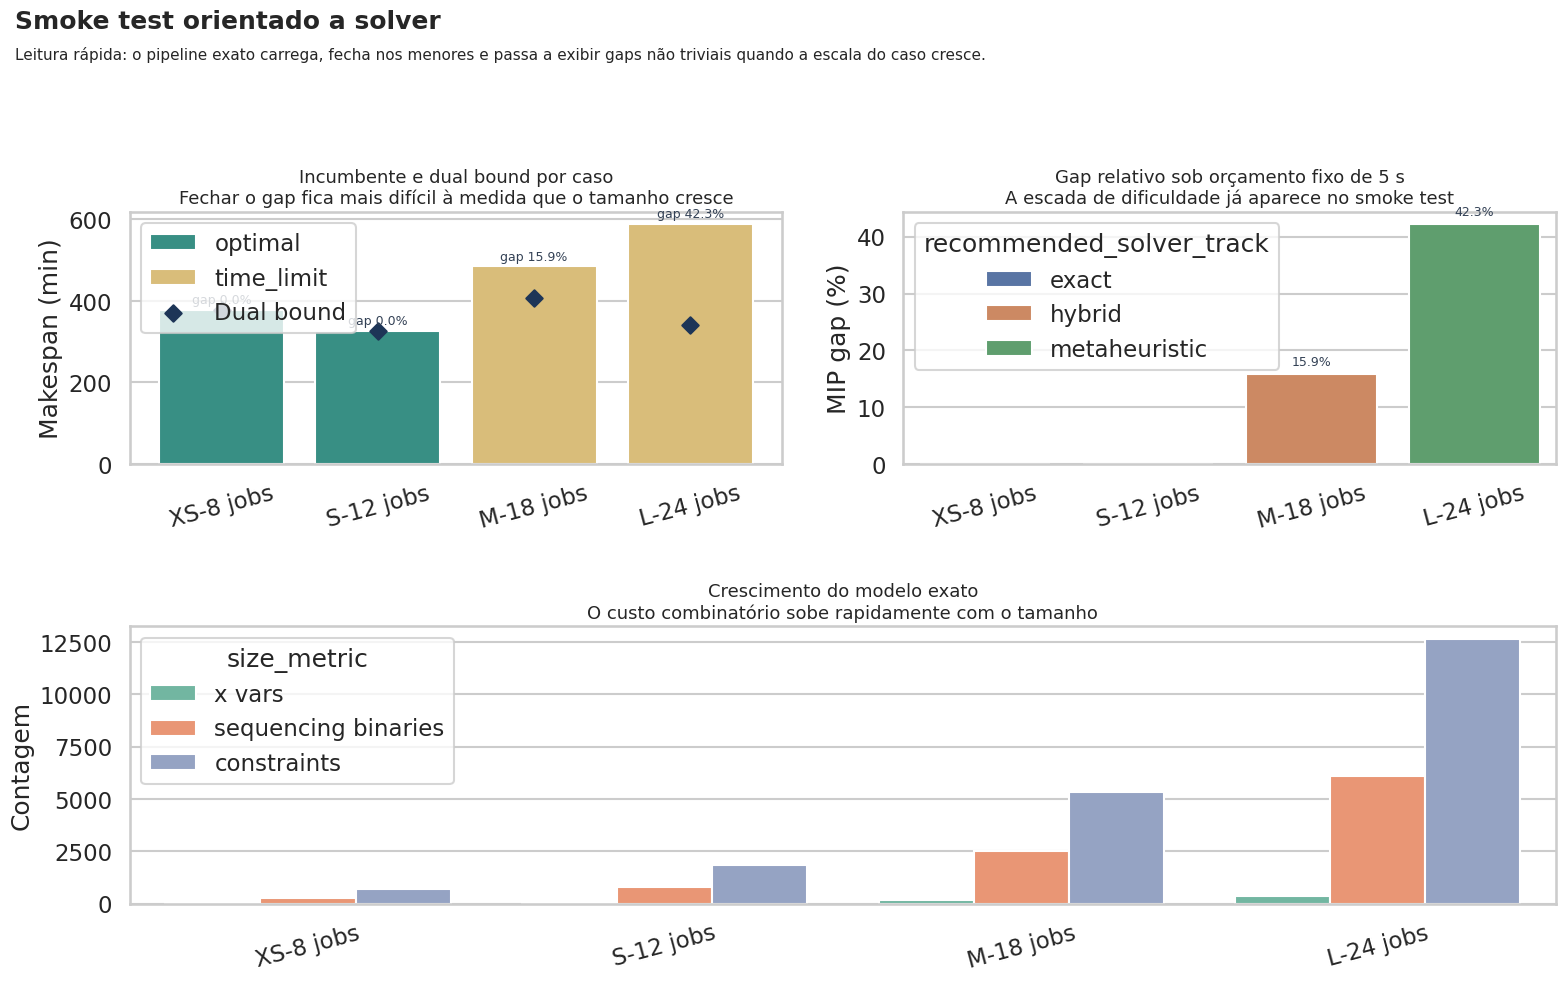

,solver_backend,time_limit_sec,small_cases_optimal,all_cases_have_solution,large_cases_nontrivial_gap,gap_non_decreasing_with_case_size
0,scipy.optimize.milp (HiGHS),5.0,True,True,True,True


In [14]:
solver_smoke_df = solver_smoke.run_smoke_suite(root=REPO_ROOT)
solver_smoke_df["case_label"] = (
    solver_smoke_df["scale_code"].astype(str)
    + "-"
    + solver_smoke_df["max_jobs"].astype(int).astype(str)
    + " jobs"
)
solver_smoke_df["gap_pct"] = solver_smoke_df["mip_gap"].fillna(1.0) * 100.0
solver_smoke_df["objective_vs_dual_gap_min"] = (
    solver_smoke_df["objective_makespan_min"] - solver_smoke_df["dual_bound_makespan_min"]
)

display(solver_smoke_df)

fig, axes = plt.subplot_mosaic(
    [["bounds", "gap"], ["size", "size"]],
    figsize=(16.0, 10.1),
    gridspec_kw={"height_ratios": [1.0, 1.1]},
)

sns.barplot(
    data=solver_smoke_df,
    x="case_label",
    y="objective_makespan_min",
    hue="status_label",
    dodge=False,
    palette={"optimal": "#2a9d8f", "time_limit": "#e9c46a", "feasible": "#8ecae6", "other": "#94a3b8", "infeasible": "#d62828"},
    ax=axes["bounds"],
)
axes["bounds"].scatter(
    range(len(solver_smoke_df)),
    solver_smoke_df["dual_bound_makespan_min"],
    color="#1d3557",
    s=70,
    marker="D",
    zorder=3,
    label="Dual bound",
)
for idx, row in solver_smoke_df.reset_index(drop=True).iterrows():
    if pd.notna(row["mip_gap"]):
        axes["bounds"].text(idx, row["objective_makespan_min"] + 8, f"gap {row['mip_gap']:.1%}", ha="center", va="bottom", fontsize=9, color="#334155")
axes["bounds"].set_title("Incumbente e dual bound por caso\nFechar o gap fica mais difícil à medida que o tamanho cresce", fontsize=13)
axes["bounds"].set_xlabel("")
axes["bounds"].set_ylabel("Makespan (min)")
axes["bounds"].tick_params(axis="x", rotation=15)
handles, labels = axes["bounds"].get_legend_handles_labels()
axes["bounds"].legend(handles, labels, loc="upper left", frameon=True)

sns.barplot(
    data=solver_smoke_df,
    x="case_label",
    y="gap_pct",
    hue="recommended_solver_track",
    dodge=False,
    palette="deep",
    ax=axes["gap"],
)
axes["gap"].set_title("Gap relativo sob orçamento fixo de 5 s\nA escada de dificuldade já aparece no smoke test", fontsize=13)
axes["gap"].set_xlabel("")
axes["gap"].set_ylabel("MIP gap (%)")
axes["gap"].tick_params(axis="x", rotation=15)
for patch in axes["gap"].patches:
    height = patch.get_height()
    if np.isfinite(height) and height > 0:
        axes["gap"].text(patch.get_x() + patch.get_width() / 2, height + 1.0, f"{height:.1f}%", ha="center", va="bottom", fontsize=9, color="#334155")

size_plot = solver_smoke_df.melt(
    id_vars=["case_label"],
    value_vars=["eligible_var_count", "machine_pair_binary_count", "constraint_count"],
    var_name="size_metric",
    value_name="count",
)
size_labels = {
    "eligible_var_count": "x vars",
    "machine_pair_binary_count": "sequencing binaries",
    "constraint_count": "constraints",
}
size_plot["size_metric"] = size_plot["size_metric"].map(size_labels)
sns.barplot(
    data=size_plot,
    x="case_label",
    y="count",
    hue="size_metric",
    ax=axes["size"],
    palette="Set2",
)
axes["size"].set_title("Crescimento do modelo exato\nO custo combinatório sobe rapidamente com o tamanho", fontsize=13)
axes["size"].set_xlabel("")
axes["size"].set_ylabel("Contagem")
axes["size"].tick_params(axis="x", rotation=15)

fig.suptitle("Smoke test orientado a solver", x=0.02, y=0.98, ha="left", fontsize=18, fontweight="bold")
fig.text(
    0.02,
    0.93,
    "Leitura rápida: o pipeline exato carrega, fecha nos menores e passa a exibir gaps não triviais quando a escala do caso cresce.",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.9), h_pad=2.0, w_pad=1.8)
plt.show()
plt.close(fig)

solver_smoke_df.to_csv(ARTIFACT_DIR / "solver_smoke_results.csv", index=False)

solver_smoke_summary = pd.DataFrame(
    [
        {
            "solver_backend": "scipy.optimize.milp (HiGHS)",
            "time_limit_sec": float(solver_smoke_df["time_limit_sec"].iloc[0]),
            "small_cases_optimal": bool(
                solver_smoke_df.loc[solver_smoke_df["max_jobs"].isin([8, 12]), "status_label"].eq("optimal").all()
            ),
            "all_cases_have_solution": bool(solver_smoke_df["has_solution"].all()),
            "large_cases_nontrivial_gap": bool(
                solver_smoke_df.loc[solver_smoke_df["max_jobs"].isin([18, 24]), "mip_gap"].fillna(0.0).ge(0.10).all()
            ),
            "gap_non_decreasing_with_case_size": bool(
                solver_smoke_df.sort_values("max_jobs")["mip_gap"].fillna(0.0).is_monotonic_increasing
            ),
        }
    ]
)
display(solver_smoke_summary)
solver_smoke_summary.to_csv(ARTIFACT_DIR / "solver_smoke_summary.csv", index=False)

**Como ler a figura acima**

- painel esquerdo: as barras são os incumbentes e os diamantes são os dual bounds; distância grande entre eles significa dificuldade residual
- painel central: sob o mesmo orçamento de tempo, `XS-8` e `S-12` fecham, enquanto `M-18` e `L-24` já preservam gaps não triviais
- painel direito: o crescimento de binárias disjuntivas e restrições explica por que a trilha recomendada migra de `exact` para `hybrid/metaheuristic`
- esta seção é um **smoke test de utilidade algorítmica**, não o protocolo final de competição entre solvers

## Instance drilldown

Um drilldown ajuda a validar visualmente se o baseline FIFO de uma instância concreta:

- respeita o fluxo por máquina
- evita overlap
- incorpora downtimes
- produz métricas coerentes com o regime escolhido

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
30,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_XS_DISRUPTED_01,XS,disrupted,1,11333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,2360242032


,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
30,GO_XS_DISRUPTED_01,instances/GO_XS_DISRUPTED_01,XS,disrupted,1,11333,24,5,2,1,2,2,0.2083,0.4583,38.33,34.12,717,140.71,288,0.0417,exact


,job_id,commodity,load_tons,arrival_time_min,reveal_time_min,priority_class,priority_weight,appointment_flag,moisture_class,statutory_wait_limit_min,completion_due_min,overwait_cost_rs_per_min,shift_bucket,arrival_congestion_score,instance_id,scale_code,regime_code,replicate,dataset_version,nominal_lb_min,due_slack_min,due_margin_over_lb_min,reveal_lead_min
1704,J0001,SOY,35,37,37,CONTRACTED,1.25,0,NORMAL,300,343,1.4058,EARLY,0.322444,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,57,306,249,0
1705,J0002,SORGHUM,31,68,68,REGULAR,1.00,0,WET,300,413,1.2452,EARLY,0.820252,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,61,345,284,0
1706,J0003,CORN,45,70,7,CONTRACTED,1.25,1,NORMAL,300,340,1.8075,EARLY,0.842879,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,60,270,210,63
1707,J0004,CORN,35,71,64,URGENT,1.75,1,NORMAL,300,318,1.4058,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,53,247,194,7
1708,J0005,CORN,44,73,73,REGULAR,1.00,0,NORMAL,300,409,1.7673,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,62,336,274,0


,completion_min,flow_time_min,queue_time_min,overwait_min,replicate
count,24.00,24.00,24.00,24.00,24.0
mean,369.42,140.71,78.92,1.42,1.0
std,190.25,71.99,71.23,6.94,0.0
min,94.00,57.00,0.00,0.00,1.0
25%,211.00,93.50,31.75,0.00,1.0
50%,354.50,126.50,66.50,0.00,1.0
75%,497.50,162.50,106.00,0.00,1.0
max,717.00,334.00,268.00,34.00,1.0


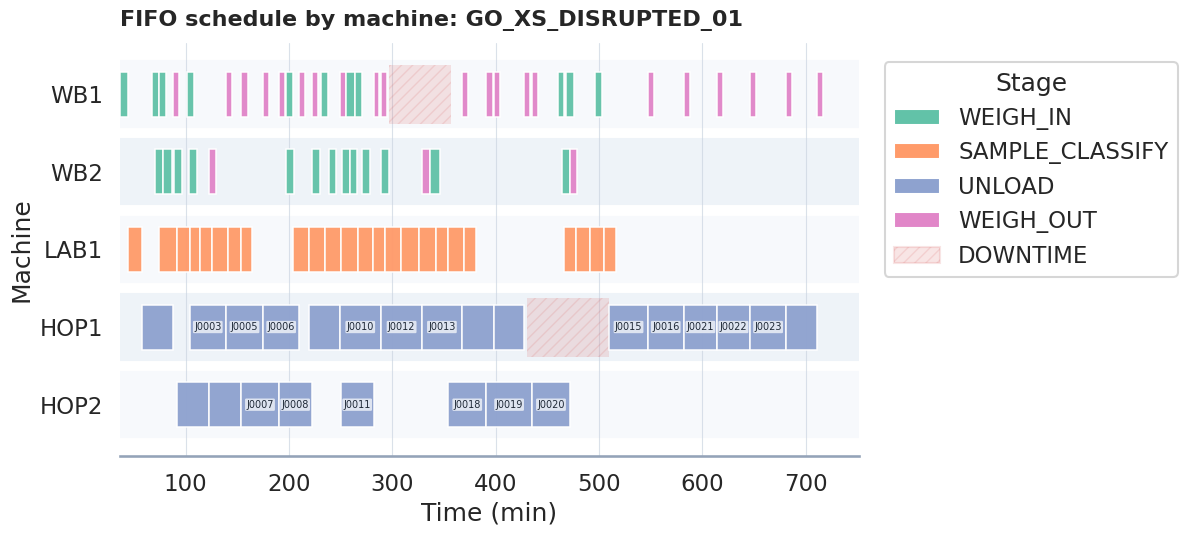

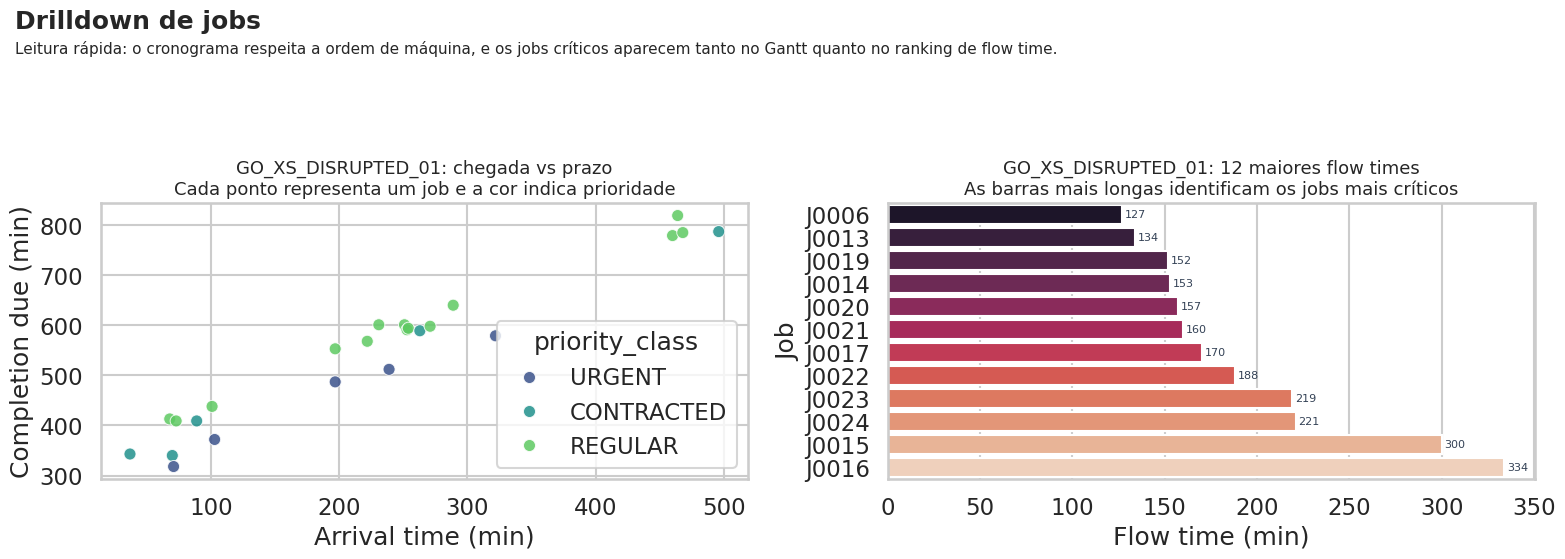

In [15]:
sample_instance = str(PIPELINE_CONFIG["sample_instance_id"])

sample_params = params[params["instance_id"] == sample_instance]
sample_summary = catalog[catalog["instance_id"] == sample_instance]
sample_jobs = jobs_enriched[jobs_enriched["instance_id"] == sample_instance]
sample_metrics = job_metrics[job_metrics["instance_id"] == sample_instance]

display(sample_params)
display(sample_summary)
display(sample_jobs.head())
display(sample_metrics.describe().round(2))

fig = repl.plot_instance_drilldown(sample_instance, ctx=NOTEBOOK_CTX, save=False)
plt.show()

fig = repl.plot_job_level_views(sample_instance, ctx=NOTEBOOK_CTX, save=False)
plt.show()

**Como ler as figuras acima**

- o Gantt mostra ocupação por máquina, faixas de downtime e ausência de overlap no baseline FIFO
- o scatter de jobs ajuda a ver como os prazos se distribuem em função da chegada
- o ranking horizontal destaca os jobs mais críticos em `flow_time`

## Results and notes

O notebook consolida uma leitura de qualidade do release oficial:

- o release está estruturalmente íntegro
- o release também é relacionalmente consistente entre arquivos, chaves e cardinalidades
- o baseline FIFO é executável contra o schema nas `36` instâncias
- os audits reconciliam os valores centrais
- os checks de regime são positivos para `mean_flow`, `p95_flow` e fila média
- o proxy médio de congestionamento é útil, mas não monotônico em todas as famílias
- a camada observacional produz um deslocamento formalmente detectável por `C2ST/MMD`, mas ainda interpretável
- as caudas `p99` e os segmentos raros continuam sob controle analítico
- o espaço de instâncias não contém duplicatas exatas nem candidatos `duplicate-like` sob o screening adotado
- `PCA` e `kNN` mostram, de forma complementar, que o release tem cobertura global e baixa redundância local
- o smoke test exato fecha nos casos menores e exibe gaps não triviais quando o tamanho da subinstância cresce
- a camada observacional reduz determinismo excessivo sem destruir semântica
- a base é forte o suficiente para servir como dataset pai de análises e futuras derivações com G2MILP

In [16]:
summary = {
    "dataset_version": manifest["dataset_version"],
    "instance_count": int(params["instance_id"].nunique()),
    "structural_pass_rate": float((structural_report["status"] == "PASS").mean()),
    "release_consistency_checks_pass": bool(release_consistency_report["pass"].all()),
    "relational_consistency_checks_pass": bool(relational_consistency_summary["pass_rate"].eq(1.0).all()),
    "fifo_schema_checks_pass": bool(
        fifo_schema_report[
            [
                "eligible_assignment_ok",
                "release_time_ok",
                "precedence_ok",
                "machine_overlap_ok",
                "downtime_ok",
            ]
        ].all(axis=None)
    ),
    "due_audit_match_share": float(audit_reconciliation["due_match_share"].mean()),
    "proc_audit_match_share": float(audit_reconciliation["proc_match_share"].mean()),
    "r2_due_slack_vs_priority": float(diagnostics["r2_due_slack_vs_priority"]),
    "r2_unload_proc_vs_load_machine_moisture": float(
        diagnostics["r2_unload_proc_vs_load_machine_moisture"]
    ),
    "flow_regime_order_checks_pass": bool(
        regime_checks["mean_flow_order_ok"].all()
        and regime_checks["p95_flow_order_ok"].all()
    ),
    "queue_regime_order_checks_pass": bool(regime_checks["mean_queue_order_ok"].all()),
    "congestion_mean_regime_order_checks_pass": bool(
        regime_checks["mean_congestion_order_ok"].all()
    ),
    "instance_space_exact_duplicate_checks_pass": bool(
        instance_space_summary.loc[0, "exact_core_duplicate_count"] == 0
        and instance_space_summary.loc[0, "exact_feature_duplicate_count"] == 0
    ),
    "instance_space_duplicate_like_checks_pass": bool(
        instance_space_summary.loc[0, "duplicate_like_candidate_count"] == 0
    ),
    "instance_space_nearest_neighbor_distance_min": float(
        instance_space_summary.loc[0, "nearest_neighbor_distance_min"]
    ),
    "job_due_c2st_auc_mean": float(
        formal_shift_summary.loc[
            formal_shift_summary["experiment"].eq("job_due_layer"), "c2st_auc_mean"
        ].iloc[0]
    ),
    "proc_time_c2st_auc_mean": float(
        formal_shift_summary.loc[
            formal_shift_summary["experiment"].eq("proc_time_layer"), "c2st_auc_mean"
        ].iloc[0]
    ),
    "tail_flow_p99_regime_order_checks_pass": bool(tail_regime_checks["flow_p99_order_ok"].all()),
    "tail_queue_p99_regime_order_checks_pass": bool(tail_regime_checks["queue_p99_order_ok"].all()),
    "tail_due_margin_p05_regime_order_checks_pass": bool(
        tail_regime_checks["due_margin_p05_order_ok"].all()
    ),
    "solver_smoke_small_cases_optimal": bool(
        solver_smoke_summary.loc[0, "small_cases_optimal"]
    ),
    "solver_smoke_all_cases_have_solution": bool(
        solver_smoke_summary.loc[0, "all_cases_have_solution"]
    ),
    "solver_smoke_large_cases_nontrivial_gap": bool(
        solver_smoke_summary.loc[0, "large_cases_nontrivial_gap"]
    ),
    "solver_smoke_gap_ladder_pass": bool(
        solver_smoke_summary.loc[0, "gap_non_decreasing_with_case_size"]
    ),
    "g2milp_role": manifest["official_dataset_role"],
}
summary_df = pd.DataFrame([summary])
display(summary_df)

summary_lines = [
    "# Notebook Summary",
    "",
    f"- Dataset version: `{summary['dataset_version']}`",
    f"- Instances: `{summary['instance_count']}`",
    f"- Structural pass rate: `{summary['structural_pass_rate']:.4f}`",
    f"- Release consistency checks pass: `{summary['release_consistency_checks_pass']}`",
    f"- Relational consistency checks pass: `{summary['relational_consistency_checks_pass']}`",
    f"- FIFO schema checks pass: `{summary['fifo_schema_checks_pass']}`",
    f"- Due audit match share: `{summary['due_audit_match_share']:.4f}`",
    f"- Proc audit match share: `{summary['proc_audit_match_share']:.4f}`",
    f"- R2 due slack vs priority: `{summary['r2_due_slack_vs_priority']:.4f}`",
    f"- R2 unload proc vs load+machine+moisture: `{summary['r2_unload_proc_vs_load_machine_moisture']:.4f}`",
    f"- Flow regime checks pass: `{summary['flow_regime_order_checks_pass']}`",
    f"- Mean queue regime checks pass: `{summary['queue_regime_order_checks_pass']}`",
    f"- Mean congestion regime checks pass: `{summary['congestion_mean_regime_order_checks_pass']}`",
    f"- Instance-space exact duplicate checks pass: `{summary['instance_space_exact_duplicate_checks_pass']}`",
    f"- Instance-space duplicate-like checks pass: `{summary['instance_space_duplicate_like_checks_pass']}`",
    f"- Instance-space nearest-neighbor distance min: `{summary['instance_space_nearest_neighbor_distance_min']:.4f}`",
    f"- Job due-layer C2ST AUC mean: `{summary['job_due_c2st_auc_mean']:.4f}`",
    f"- Proc-time layer C2ST AUC mean: `{summary['proc_time_c2st_auc_mean']:.4f}`",
    f"- Tail flow p99 regime checks pass: `{summary['tail_flow_p99_regime_order_checks_pass']}`",
    f"- Tail queue p99 regime checks pass: `{summary['tail_queue_p99_regime_order_checks_pass']}`",
    f"- Tail due-margin p05 regime checks pass: `{summary['tail_due_margin_p05_regime_order_checks_pass']}`",
    f"- Solver smoke small cases optimal: `{summary['solver_smoke_small_cases_optimal']}`",
    f"- Solver smoke all cases have solution: `{summary['solver_smoke_all_cases_have_solution']}`",
    f"- Solver smoke large cases show non-trivial gap: `{summary['solver_smoke_large_cases_nontrivial_gap']}`",
    f"- Solver smoke gap ladder pass: `{summary['solver_smoke_gap_ladder_pass']}`",
    f"- Official role: `{summary['g2milp_role']}`",
]
summary_text = "\n".join(summary_lines)
(ARTIFACT_DIR / "notebook_summary.md").write_text(summary_text, encoding="utf-8")
summary_df.to_csv(ARTIFACT_DIR / "notebook_summary.csv", index=False)
display(Markdown(summary_text))

,dataset_version,instance_count,structural_pass_rate,release_consistency_checks_pass,relational_consistency_checks_pass,fifo_schema_checks_pass,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,instance_space_exact_duplicate_checks_pass,instance_space_duplicate_like_checks_pass,instance_space_nearest_neighbor_distance_min,job_due_c2st_auc_mean,proc_time_c2st_auc_mean,tail_flow_p99_regime_order_checks_pass,tail_queue_p99_regime_order_checks_pass,tail_due_margin_p05_regime_order_checks_pass,solver_smoke_small_cases_optimal,solver_smoke_all_cases_have_solution,solver_smoke_large_cases_nontrivial_gap,solver_smoke_gap_ladder_pass,g2milp_role
0,1.1.0-observed,36,1.0,False,True,True,1.0,1.0,0.4848,0.4995,True,True,False,True,True,2.322821,0.777706,0.597995,False,False,False,True,True,True,True,base_dataset_for_g2milp_instance_generation


# Notebook Summary

- Dataset version: `1.1.0-observed`
- Instances: `36`
- Structural pass rate: `1.0000`
- Release consistency checks pass: `False`
- Relational consistency checks pass: `True`
- FIFO schema checks pass: `True`
- Due audit match share: `1.0000`
- Proc audit match share: `1.0000`
- R2 due slack vs priority: `0.4848`
- R2 unload proc vs load+machine+moisture: `0.4995`
- Flow regime checks pass: `True`
- Mean queue regime checks pass: `True`
- Mean congestion regime checks pass: `False`
- Instance-space exact duplicate checks pass: `True`
- Instance-space duplicate-like checks pass: `True`
- Instance-space nearest-neighbor distance min: `2.3228`
- Job due-layer C2ST AUC mean: `0.7777`
- Proc-time layer C2ST AUC mean: `0.5980`
- Tail flow p99 regime checks pass: `False`
- Tail queue p99 regime checks pass: `False`
- Tail due-margin p05 regime checks pass: `False`
- Solver smoke small cases optimal: `True`
- Solver smoke all cases have solution: `True`
- Solver smoke large cases show non-trivial gap: `True`
- Solver smoke gap ladder pass: `True`
- Official role: `base_dataset_for_g2milp_instance_generation`

## Next steps

- usar este notebook como baseline de validação antes de gerar filhos com G2MILP
- ampliar com comparações entre esta release oficial e futuros datasets derivados
- adicionar testes de sensibilidade por família de máquina ou por política de geração

# Full Paper Pipeline

A partir daqui o notebook deixa de ser apenas uma auditoria do release e passa a
executar o pipeline completo pedido em `paper/Artigo.md`.

**Nota metodológica**

- `M0` é o baseline oficial do release observado.
- `M1`, `M2` e `M3` são implementados como um benchmark reproduzível de
  list-scheduling com políticas diferentes de ordenação e reatividade.
- `E6` também gera bundles derivados de instâncias-filhas `graded` e
  `discriminating`, com eventos e baseline FIFO replayados no próprio notebook.

In [17]:
ARTICLE_FIGURE_DIR = REPO_ROOT / "output" / "article_figures"
ARTICLE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

catalog_dir = REPO_ROOT / "catalog"
paper_results = paper.load_or_run_full_pipeline(
    root=ANALYSIS_ROOT,
    ctx=NOTEBOOK_CTX,
    figure_dir=ARTICLE_FIGURE_DIR,
    catalog_dir=catalog_dir,
)
paper_features = paper_results.feature_frame.copy()
method_matrix = paper_results.performance.copy()
method_matrix_test = paper_results.performance_test.copy()
protocol_split_summary = paper_results.protocol_summary.copy()
umap_frame = paper_results.umap_frame.copy()
selector_report = paper_results.selector_report.copy()
selector_shap = paper_results.shap_frame.copy()
scorecard_release = paper_results.scorecard.copy()

display(paper_features.head())
display(protocol_split_summary)
display(method_matrix.head())
display(method_matrix_test.head())
display(selector_report)


/tmp/ipykernel_19868/1001623704.py:250: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  frame = frame.fillna(0.0)


/home/marcusvinicius/.local/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/marcusvinicius/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserW

,instance_id,scale_code,regime_code,replicate,planning_horizon_min,core_instance_digest,n_jobs,appointment_share_x,urgent_share_x,contracted_share,commodity_nunique,moisture_nunique,load_mean,load_std,due_margin_mean,due_margin_std,arrival_mean,arrival_std,congestion_mean,congestion_std,eligible_machine_mean,eligible_machine_std,eligible_machine_min,eligible_machine_max,eligible_rows,proc_time_mean,proc_time_std,proc_time_min,proc_time_max,wb_machine_count,lab_machine_count,hop_machine_count,machine_count,downtime_count,downtime_total_min_x,flow_mean,flow_p95,queue_mean,queue_p95,wb_utilization_mean,lab_utilization_mean,hop_utilization_mean,pc1,pc2,nearest_neighbor_instance_id,nearest_neighbor_distance,exact_core_duplicate,exact_feature_duplicate,duplicate_like_candidate,due_slack_mean,due_slack_std,due_slack_p10,due_slack_p90,urgent_share_y,appointment_share_y,commodity_entropy,moisture_entropy,wet_share,event_count,first_event_min,last_event_min,visible_jobs_at_t0,inter_event_mean,inter_event_std,compatibility_density,proc_time_cv,downtime_total_min_y,downtime_max_machine_share,visible_jobs_fraction_t0,reveal_span_min,bottleneck_utilization,bottleneck_machine_family,size_hint,regime_hint
0,GO_L_BALANCED_01,L,balanced,1,1080.0,d08ecf0837ba4e4f8700c9806bb788a5d04320c734fb58...,72.0,0.750000,0.027778,0.236111,3.0,3.0,38.777778,3.022089,240.611111,23.300581,340.097222,140.704481,0.624051,0.282566,3.628472,0.484054,3.0,4.0,1045.0,12.168421,7.370878,5.0,36.0,0.0,3.0,0.0,3.0,0.0,0.0,52.986111,68.45,4.597222,17.90,0.0,0.262654,0.0,4.693149,1.863620,GO_L_BALANCED_02,2.900777,False,False,False,286.388889,23.457817,257.0,312.9,0.027778,0.750000,1.204582,1.374985,0.208333,144,0,618,3,4.321678,5.338673,1.209491,0.605448,0.0,0.000000,0.041667,618,0.262654,LAB,3,0
1,GO_L_BALANCED_02,L,balanced,2,1080.0,21b3bafdfa6a30d67f81f11d84a9eccbbcb8cfcff36354...,72.0,0.750000,0.027778,0.138889,3.0,3.0,37.888889,3.295561,246.236111,18.499709,328.972222,139.216315,0.594889,0.258773,3.604167,0.489880,3.0,4.0,1038.0,12.251445,7.552157,5.0,36.0,0.0,3.0,0.0,3.0,0.0,0.0,58.694444,87.35,8.958333,35.45,0.0,0.288272,0.0,4.472980,1.746439,GO_L_BALANCED_01,2.900777,False,False,False,291.611111,19.091740,267.0,312.8,0.027778,0.750000,1.463806,1.450958,0.291667,144,0,636,6,4.447552,5.817262,1.201389,0.616133,0.0,0.000000,0.083333,636,0.288272,LAB,3,0
2,GO_L_BALANCED_03,L,balanced,3,1080.0,a7ddb6ac24590dca3148b2c01163aaa96317ea9bd15fa2...,72.0,0.750000,0.027778,0.138889,3.0,3.0,38.805556,3.142794,262.555556,17.897115,315.833333,149.727828,0.705372,0.211085,3.628472,0.484054,3.0,4.0,1045.0,12.514833,8.210766,5.0,38.0,0.0,3.0,0.0,3.0,0.0,0.0,50.444444,57.00,1.472222,7.90,0.0,0.260185,0.0,4.856458,1.266347,GO_L_BALANCED_02,3.433960,False,False,False,308.708333,18.747723,285.2,331.7,0.027778,0.750000,1.287062,1.303170,0.166667,144,0,606,7,4.237762,5.618077,1.209491,0.655769,0.0,0.000000,0.097222,606,0.260185,LAB,3,0
3,GO_L_DISRUPTED_01,L,disrupted,1,1080.0,5b0931b0ae26b02ceab19434a3083da1d14dabf92dad78...,96.0,0.593750,0.197917,0.125000,3.0,3.0,38.572917,2.947773,258.427083,31.059110,238.427083,152.262152,0.712664,0.245161,3.606771,0.489104,3.0,4.0,1385.0,13.589170,9.188270,5.0,42.0,0.0,3.0,0.0,3.0,3.0,171.0,101.031250,148.25,45.895833,95.50,0.0,0.410494,0.0,2.368992,-4.826220,GO_L_DISRUPTED_03,2.336918,False,False,False,309.302083,31.644113,260.5,343.5,0.197917,0.593750,1.398209,1.344636,0.395833,198,0,569,10,2.888325,5.754121,1.202257,0.675902,171.0,0.479532,0.104167,569,0.410494,LAB,3,2
4,GO_L_DISRUPTED_02,L,disrupted,2,1080.0,3da3bc11ed94aa1f91b8336d098a6d82bc1c9f478b2ccd...,96.0,0.635417,0.177083,0.187500,3.0,3.0,37.854167,2.651630,269.208333,33.467004,234.239583,152.943797,0.684268,0.238827,3.588542,0.492740,3.0,4.0,1378.0,12.301161,7.419283,5.0,39.0,0.0,3.0,0.0,3.0,2.0,158.0,93.395833,150.00,42.854167,97.25,0.0,0.400309,0.0,3.519730,-4.541526,GO_L_DISRUPTED_03,3.016497,False,False,False,315.395833,33.745636,268.0,349.5,0.177083,0.635417,1.296029,1.348106,0.40625

,instance_id,flow_mean,flow_p95,queue_mean,queue_p95,makespan,weighted_tardiness,runtime_sec,replan_count,solver_status,method_name,scale_code,regime_code,replicate,mip_gap,exact_job_count,fifo_flow_mean,fifo_flow_p95,fifo_makespan,delta_vs_fifo_mean_flow_pct,delta_vs_fifo_p95_flow_pct,delta_vs_fifo_makespan_pct,flow_p95_norm,flow_mean_norm,makespan_norm,weighted_tardiness_norm,runtime_sec_norm,utility,regret,best_method,best_utility,difficulty,footprint_member
0,GO_L_BALANCED_01,52.986111,68.45,4.597222,17.90,670.0,0.00,0.000000,1,official_release,M0_FIFO_OFFICIAL,L,balanced,1,NaN,NaN,52.986111,68.45,670.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,M0_FIFO_OFFICIAL,0.0,easy,True
1,GO_L_BALANCED_01,378.458333,775.15,329.625000,727.60,961.0,9903.75,0.140826,1,heuristic_feasible,M1_WEIGHTED_SLACK,L,balanced,1,NaN,NaN,52.986111,68.45,670.0,6.142595,10.324324,0.434328,1.000000,1.000000,1.000000,1.000000,0.055488,0.952774,0.952774,M0_FIFO_OFFICIAL,0.0,easy,False
2,GO_L_BALANCED_01,154.111111,296.45,105.416667,250.50,759.0,198.50,0.143250,29,heuristic_feasible,M2_PERIODIC_15,L,balanced,1,NaN,NaN,52.986111,68.45,670.0,1.908519,3.330898,0.132836,0.322626,0.310702,0.305842,0.020043,0.056443,0.273560,0.273560,M0_FIFO_OFFICIAL,0.0,easy,False
3,GO_L_BALANCED_01,159.375000,296.95,110.597222,249.15,785.0,238.75,0.137848,18,heuristic_feasible,M2_PERIODIC_30,L,balanced,1,NaN,NaN,52.986111,68.45,670.0,2.007864,3.338203,0.171642,0.323334,0.326875,0.395189,0.024107,0.054315,0.291624,0.291624,M0_FIFO_OFFICIAL,0.0,easy,False
4,GO_L_BALANCED_01,155.166667,277.80,106.083333,229.35,741.0,127.75,0.138518,64,heuristic_feasible,M3_EVENT_REACTIVE,L,balanced,1,NaN,NaN,52.986111,68.45,670.0,1.928440,3.058437,0.105970,0.296236,0.313946,0.243986,0.012899,0.054579,0.252409,0.252409,M0_FIFO_OFFICIAL,0.0,easy,False


,model_name,top1_accuracy,macro_f1,balanced_accuracy
0,decision_tree,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0
2,lightgbm,1.0,1.0,1.0


## Cobertura do `paper/Artigo.md`

O notebook continua sendo a camada visível do paper. O que mudou foi só a implementação: a lógica foi movida para `experiments/agro_yard_paper`, mas tudo que precisa aparecer para leitura do artigo continua exposto aqui.

O bloco abaixo mantém, de forma auditável e visível no notebook:

- os métodos do artigo: `M0`, `M1`, `M2`, `M3`, `M4` e `Mref`;
- os experimentos do artigo: `E0`, `E1`, `E1b`, `E2`, `E2b`, `E3`, `E4`, `E5`, `E6`;
- as tabelas, figuras e diagnósticos que sustentam cada experimento;
- o vínculo explícito com o protocolo descrito em `paper/Artigo.md`.

Esta tabela responde de forma direta à pergunta "todo o paper foi implementado?".
O status é intencionalmente explícito para não mascarar lacunas.


In [18]:
coverage_table = paper.build_experiment_coverage_table()
display(coverage_table)


,item_type,item_name,status,notes
0,method,M0_FIFO_OFFICIAL,implemented,usa os artefatos oficiais do release observado
1,method,M1_WEIGHTED_SLACK,implemented,heurística estática reproduzível no notebook
2,method,M2_PERIODIC_15,implemented,proxy periódico com Δ=15 min
3,method,M2_PERIODIC_30,implemented,proxy periódico com Δ=30 min
4,method,M3_EVENT_REACTIVE,implemented,proxy reativo disparado por reveal/eventos obs...
5,method,M4_METAHEURISTIC_L,implemented,busca local metaheurística com orçamento compu...
6,method,Mref_EXACT_XS_S,implemented,referência exata via subproblema otimizado e e...
7,experiment,E0_benchmark_audit,implemented,"validadores, auditoria estrutural e replay pró..."
8,experiment,E1_main_comparison,implemented,"comparação M0/M1/M2/M3 com utilidade, regret e..."
9,experiment,E2_periodic_vs_event,implemented,comparação explícita entre M2 e M3 com métrica...


## E0. Reprodutibilidade e auditoria do benchmark

Este experimento consolida:

- validação estrutural do release observado;
- consistência relacional entre os arquivos centrais;
- replay próprio de `M0` contra os artefatos oficiais.

In [19]:
fifo_replay_diff = paper.build_fifo_replay_diff_table(root=ANALYSIS_ROOT, ctx=NOTEBOOK_CTX)
fifo_replay_diff.to_csv(REPO_ROOT / "catalog" / "fifo_replay_diff.csv", index=False)
e0_audit_snapshot = paper.build_e0_audit_snapshot(
    summary=summary,
    structural_report=structural_report,
    relational_consistency_summary=relational_consistency_summary,
)
display(e0_audit_snapshot)
display(fifo_replay_diff.head(12))
display(structural_report.sort_values(["scale_code", "regime_code", "instance_id"]).head(12))
display(relational_consistency_summary)


,check_name,value,status
0,validate_observed_release_pass_rate,1.0,implemented
1,relational_consistency_pass_rate,1.0,implemented
2,benchmark_validator_issue_count,0.0,implemented
3,fifo_custom_replay_diff_table,0.0,implemented


,instance_id,schedule_row_diff,flow_mean_abs_diff,flow_p95_abs_diff,makespan_abs_diff,queue_mean_abs_diff,replay_runtime_sec,replay_solver_status,replay_job_count
0,GO_L_BALANCED_01,0,16.361111,48.55,0.0,16.166667,0.142573,heuristic_feasible,72
1,GO_L_BALANCED_02,0,21.666667,34.10,0.0,21.555556,0.142621,heuristic_feasible,72
2,GO_L_BALANCED_03,0,6.291667,14.45,0.0,6.208333,0.181564,heuristic_feasible,72
3,GO_L_DISRUPTED_01,0,93.687500,140.50,169.0,94.270833,0.183438,heuristic_feasible,96
4,GO_L_DISRUPTED_02,0,68.729167,93.50,100.0,68.968750,0.181608,heuristic_feasible,96
5,GO_L_DISRUPTED_03,0,88.781250,141.50,187.0,89.739583,0.181249,heuristic_feasible,96
6,GO_L_PEAK_01,0,57.031250,95.00,97.0,57.656250,0.181144,heuristic_feasible,96
7,GO_L_PEAK_02,0,89.177083,118.25,127.0,89.750000,0.180244,heuristic_feasible,96
8,GO_L_PEAK_03,0,39.812500,72.25,24.0,40.052083,0.181280,heuristic_feasible,96
9,GO_M_BALANCED_01,0,10.250000,29.55,1.0,9.666667,0.090007,heuristic_feasible,48


,instance_id,issue_count,issues,status,scale_code,regime_code
0,GO_L_BALANCED_01,0,,PASS,L,balanced
1,GO_L_BALANCED_02,0,,PASS,L,balanced
2,GO_L_BALANCED_03,0,,PASS,L,balanced
3,GO_L_DISRUPTED_01,0,,PASS,L,disrupted
4,GO_L_DISRUPTED_02,0,,PASS,L,disrupted
5,GO_L_DISRUPTED_03,0,,PASS,L,disrupted
6,GO_L_PEAK_01,0,,PASS,L,peak
7,GO_L_PEAK_02,0,,PASS,L,peak
8,GO_L_PEAK_03,0,,PASS,L,peak
9,GO_M_BALANCED_01,0,,PASS,M,balanced


,check_name,pass_rate,failed_instance_count
0,every_operation_has_eligible_machine_ok,1.0,0
1,fifo_has_one_row_per_operation_ok,1.0,0
2,job_events_fk_ok,1.0,0
3,job_has_3_precedences_ok,1.0,0
4,job_has_4_operations_ok,1.0,0
5,machine_events_fk_ok,1.0,0
6,metrics_job_fk_ok,1.0,0
7,schedule_machine_fk_ok,1.0,0
8,schedule_operation_fk_ok,1.0,0


## E1. Comparação principal entre métodos

Este bloco entrega a tabela base do paper:

- `M0_FIFO_OFFICIAL`
- `M1_WEIGHTED_SLACK`
- `M2_PERIODIC_15`
- `M2_PERIODIC_30`
- `M3_EVENT_REACTIVE`
- `Mref_EXACT_XS_S`
- `M4_METAHEURISTIC_L`

As métricas principais são `flow_mean`, `flow_p95`, `makespan`,
`weighted_tardiness`, `runtime_sec`, `utility` e `regret`.

In [20]:
method_summary = (
    method_matrix_test.groupby(["method_name", "scale_code"], as_index=False)
    .agg(
        flow_mean=("flow_mean", "mean"),
        flow_p95=("flow_p95", "mean"),
        runtime_sec=("runtime_sec", "mean"),
        utility=("utility", "mean"),
        delta_vs_fifo_p95_flow_pct=("delta_vs_fifo_p95_flow_pct", "mean"),
    )
)
display(protocol_split_summary)
display(method_summary.sort_values(["scale_code", "utility", "method_name"]))
display(
    method_matrix_test[
        [
            "instance_id",
            "protocol_role",
            "method_name",
            "flow_mean",
            "flow_p95",
            "makespan",
            "weighted_tardiness",
            "runtime_sec",
            "utility",
            "regret",
            "difficulty",
        ]
    ].head(20)
)

,method_name,scale_code,flow_mean,flow_p95,runtime_sec,utility,delta_vs_fifo_p95_flow_pct
0,M0_FIFO_OFFICIAL,L,77.476852,117.255556,0.000000,0.000000,0.000000
16,M3_EVENT_REACTIVE,L,210.876157,347.294444,0.169310,0.267772,2.158461
8,M2_PERIODIC_15,L,217.304398,355.133333,0.183550,0.278435,2.263340
20,M4_METAHEURISTIC_L,L,198.568287,328.188889,3.152195,0.287391,2.018211
12,M2_PERIODIC_30,L,237.162809,381.794444,0.167851,0.316355,2.477650
4,M1_WEIGHTED_SLACK,L,493.105324,917.705556,0.181471,0.952866,7.492225
1,M0_FIFO_OFFICIAL,M,74.407986,106.216667,0.000000,0.000000,0.000000
17,M3_EVENT_REACTIVE,M,205.621528,338.833333,0.125547,0.291676,2.375205
9,M2_PERIODIC_15,M,211.294560,341.888889,0.115654,0.299629,2.369524
13,M2_PERIODIC_30,M,214.218171,342.911111,0.129137,0.302635,2.435106


,instance_id,method_name,flow_mean,flow_p95,makespan,weighted_tardiness,runtime_sec,utility,regret,difficulty
0,GO_L_BALANCED_01,M0_FIFO_OFFICIAL,52.986111,68.45,670.0,0.00,0.000000,0.000000,0.000000,easy
1,GO_L_BALANCED_01,M1_WEIGHTED_SLACK,378.458333,775.15,961.0,9903.75,0.140826,0.952774,0.952774,easy
2,GO_L_BALANCED_01,M2_PERIODIC_15,154.111111,296.45,759.0,198.50,0.143250,0.273560,0.273560,easy
3,GO_L_BALANCED_01,M2_PERIODIC_30,159.375000,296.95,785.0,238.75,0.137848,0.291624,0.291624,easy
4,GO_L_BALANCED_01,M3_EVENT_REACTIVE,155.166667,277.80,741.0,127.75,0.138518,0.252409,0.252409,easy
5,GO_L_BALANCED_01,M4_METAHEURISTIC_L,146.388889,268.00,727.0,78.75,2.537946,0.278987,0.278987,easy
6,GO_L_BALANCED_02,M0_FIFO_OFFICIAL,58.694444,87.35,681.0,0.00,0.000000,0.000000,0.000000,easy
7,GO_L_BALANCED_02,M1_WEIGHTED_SLACK,423.319444,814.05,1024.0,12735.50,0.138955,0.952762,0.952762,easy
8,GO_L_BALANCED_02,M2_PERIODIC_15,147.694444,265.90,740.0,71.75,0.140652,0.200747,0.200747,easy
9,GO_L_BALANCED_02,M2_PERIODIC_30,161.041667,287.25,735.0,82.75,0.138355,0.220974,0.220974,easy


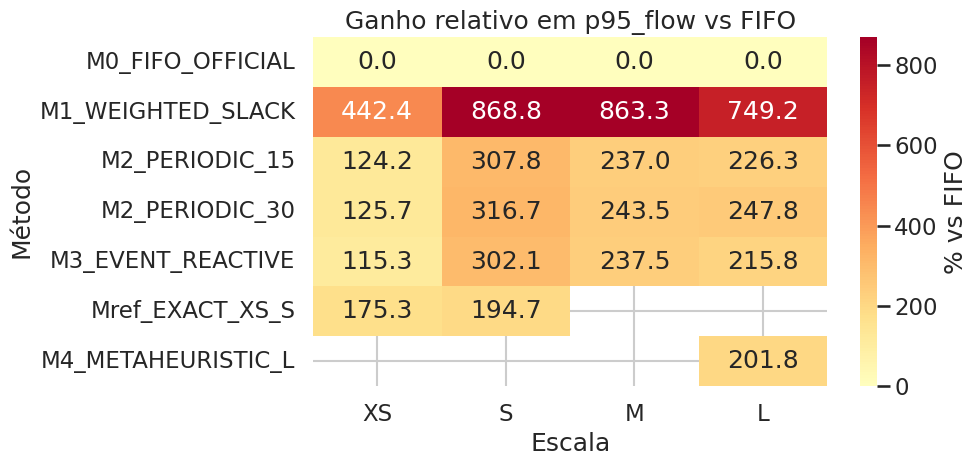

In [21]:
fig = paper.plot_method_delta(method_matrix_test)
plt.show()
plt.close(fig)


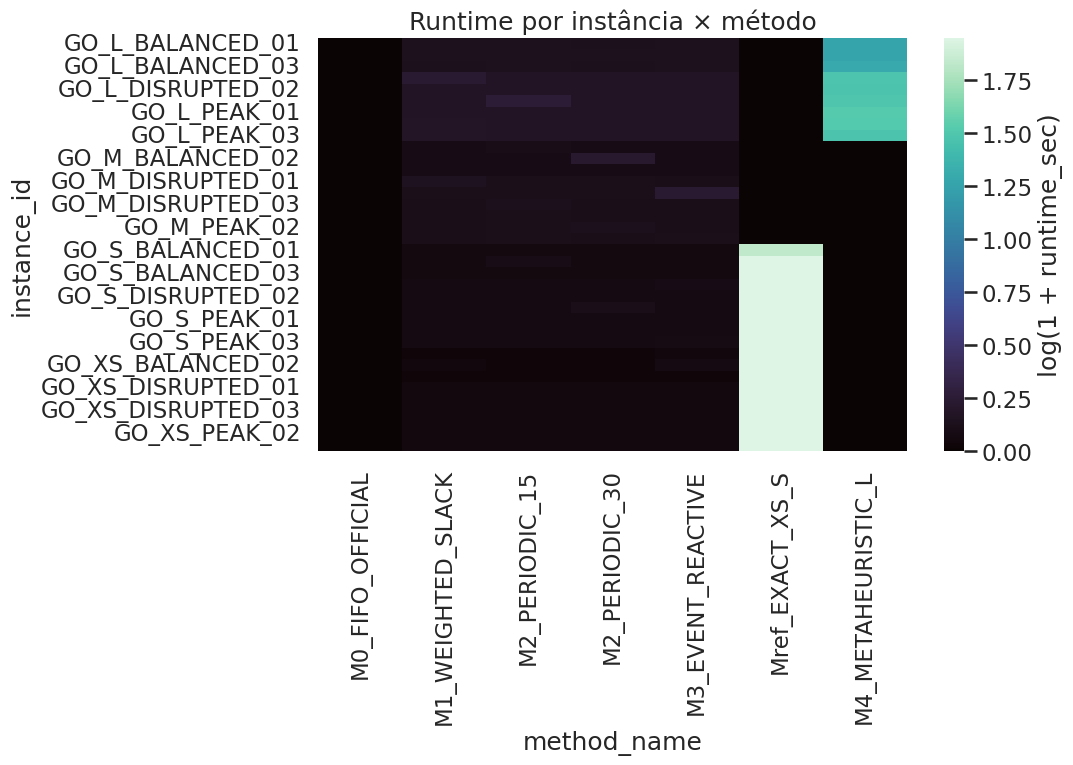

In [22]:
fig = paper.plot_method_runtime(method_matrix_test)
plt.show()
plt.close(fig)


## E1b. Performance profiles

Médias escondem dominância parcial e robustez. Este bloco plota o perfil de
desempenho usando a `utility` agregada do artigo.

In [23]:
performance_profile = paper.build_performance_profile_frame(method_matrix_test, value_col="utility")
display(performance_profile.head())


,method_name,tau,share_instances
0,M0_FIFO_OFFICIAL,1.000000,1.0
1,M0_FIFO_OFFICIAL,1.012605,1.0
2,M0_FIFO_OFFICIAL,1.025210,1.0
3,M0_FIFO_OFFICIAL,1.037815,1.0
4,M0_FIFO_OFFICIAL,1.050420,1.0


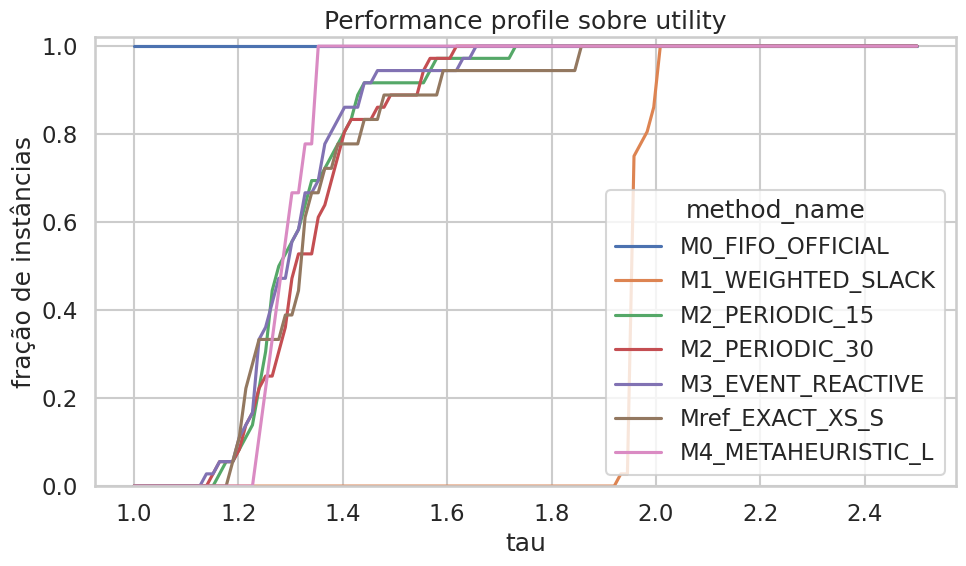

In [24]:
paper.plot_performance_profile(performance_profile)


## E2. Periódico versus disparado por eventos

Aqui isolamos a pergunta central da revisão:

- `M2_PERIODIC_15`
- `M2_PERIODIC_30`
- `M3_EVENT_REACTIVE`

O notebook mede `flow`, `runtime`, `utility`, `regret`, `replan_count`
e separa a troca entre controle periódico e evento reativo.

In [25]:
e2_tradeoff = paper.build_e2_tradeoff_table(method_matrix_test)
display(e2_tradeoff)


,method_name,scale_code,regime_code,flow_mean,flow_p95,runtime_sec,replan_count,utility,regret,delta_vs_fifo_p95_flow_pct
0,M3_EVENT_REACTIVE,L,balanced,146.319444,272.050000,0.139217,63.666667,0.228968,0.228968,2.950620
1,M2_PERIODIC_15,L,balanced,149.013889,284.316667,0.141743,29.000000,0.246325,0.246325,3.157740
2,M2_PERIODIC_30,L,balanced,160.564815,298.216667,0.138032,18.000000,0.270365,0.270365,3.357730
3,M3_EVENT_REACTIVE,L,disrupted,257.000000,390.000000,0.184990,74.000000,0.300182,0.300182,1.668012
4,M2_PERIODIC_15,L,disrupted,264.784722,398.166667,0.223704,28.333333,0.308806,0.308806,1.719518
5,M2_PERIODIC_30,L,disrupted,292.579861,428.000000,0.182933,16.666667,0.355228,0.355228,1.918456
6,M3_EVENT_REACTIVE,L,peak,229.309028,379.833333,0.183722,78.333333,0.274167,0.274167,1.856751
7,M2_PERIODIC_15,L,peak,238.114583,382.916667,0.185203,31.666667,0.280176,0.280176,1.912761
8,M2_PERIODIC_30,L,peak,258.343750,419.166667,0.182588,18.333333,0.323471,0.323471,2.156765
9,M3_EVENT_REACTIVE,M,balanced,147.395833,276.383333,0.090720,43.333333,0.258055,0.258055,3.150393


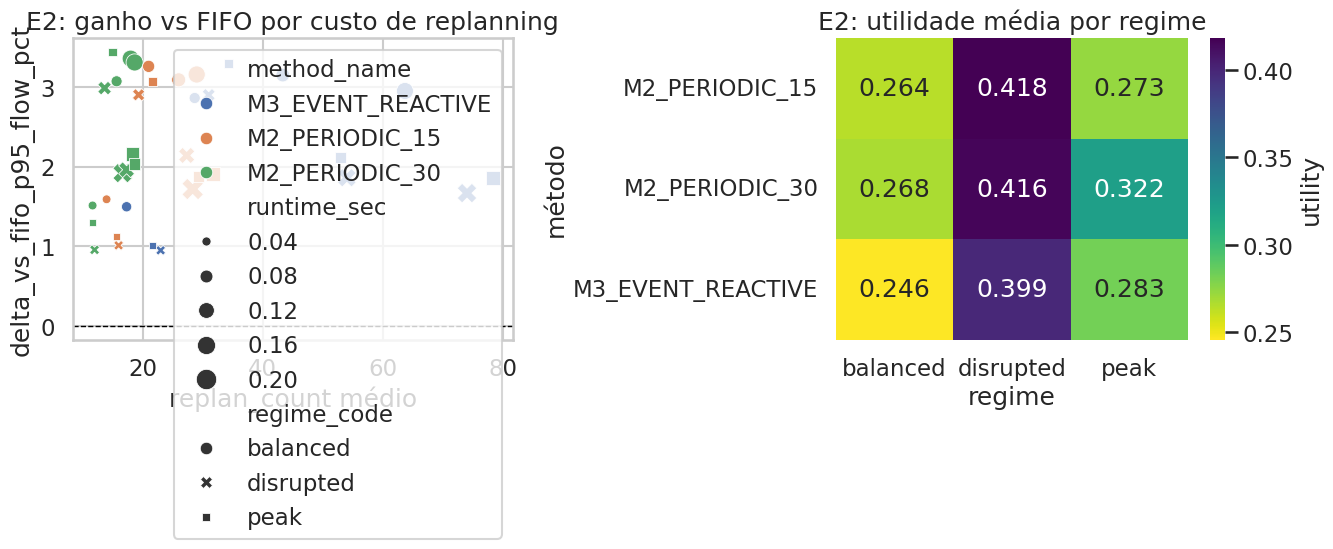

In [26]:
paper.plot_e2_tradeoff(e2_tradeoff)


## E2b. Sensibilidade computacional a budget, threads e paralelismo

Este bloco roda um estudo controlado com:

- budgets `short`, `medium`, `long`;
- `n_workers / threads` em `{1, 2}`;
- métodos com knobs computacionais explícitos (`M2`, `M3`, `Mref`, `M4`);
- um conjunto representativo com uma instância `replicate=01` por escala.

In [27]:
compute_sensitivity_path = REPO_ROOT / "catalog" / "compute_sensitivity.csv"
sensitivity_catalog = NOTEBOOK_CTX["catalog"][["instance_id", "scale_code", "regime_code", "replicate"]].drop_duplicates().copy()
e2b_sensitivity = paper.load_or_run_compute_sensitivity(
    root=ANALYSIS_ROOT,
    catalog=sensitivity_catalog,
    out_path=compute_sensitivity_path,
)


,instance_id,scale_code,regime_code,method_name,budget_label,budget_sec,n_workers,threads,runtime_sec,replan_count,solver_status,flow_mean,flow_p95,makespan,weighted_tardiness,plan_instability,flow_p95_norm,flow_mean_norm,makespan_norm,weighted_tardiness_norm,runtime_sec_norm,utility
0,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,short,1.0,1,1,1.208893,64.0,metaheuristic_workers_1,142.583333,265.05,753.0,49.00,NaN,0.170901,0.379130,1.000000,0.474576,0.016695,0.369980
1,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,short,1.0,2,2,1.225986,64.0,metaheuristic_workers_2,142.555556,271.35,737.0,78.75,NaN,0.461894,0.377391,0.448276,0.762712,0.020441,0.446735
2,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,medium,2.5,1,1,2.676562,64.0,metaheuristic_workers_1,138.500000,261.90,726.0,1.75,0.000000,0.025404,0.123478,0.068966,0.016949,0.338323,0.071257
3,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,medium,2.5,2,2,3.215370,64.0,metaheuristic_workers_2,140.791667,264.45,734.0,78.75,0.302083,0.143187,0.266957,0.344828,0.762712,0.456399,0.281989
4,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,long,5.0,1,1,5.282683,64.0,metaheuristic_workers_1,136.527778,261.35,724.0,0.00,0.388889,0.000000,0.000000,0.000000,0.000000,0.909435,0.045472
5,GO_L_BALANCED_01,L,balanced,M2_PERIODIC_15,long,5.0,2,2,5.036011,64.0,metaheuristic_workers_2,141.611111,268.60,730.0,0.00,0.725694,0.334873,0.318261,0.206897,0.000000,0.855379,0.304061
6,GO_L_BALANCED_01,L,balanced,M3_EVENT_REACTIVE,short,1.0,1,1,1.134277,64.0,metaheuristic_workers_1,150.847222,273.90,734.0,103.25,NaN,0.579677,0.896522,0.344828,1.000000,0.000343,0.636726
7,GO_L_BALANCED_01,L,balanced,M3_EVENT_REACTIVE,short,1.0,2,2,1.348607,64.0,metaheuristic_workers_2,150.847222,273.90,734.0,103.25,NaN,0.579677,0.896522,0.344828,1.000000,0.047312,0.639075
8,GO_L_BALANCED_01,L,balanced,M3_EVENT_REACTIVE,medium,2.5,1,1,2.594139,64.0,metaheuristic_workers_1,151.402778,274.45,743.0,101.50,0.000000,0.605081,0.931304,0.655172,0.983051,0.320261,0.717706
9,GO_L_BALANCED_01,L,balanced,M3_EVENT_REACTIVE,medium,2.5,2,2,2.590101,64.0,metaheuristic_workers_2,151.402778,274.45,743.0,101.50,0.000000,0.605081,0.931304,0.655172,0.983051,0.319376,0.717662


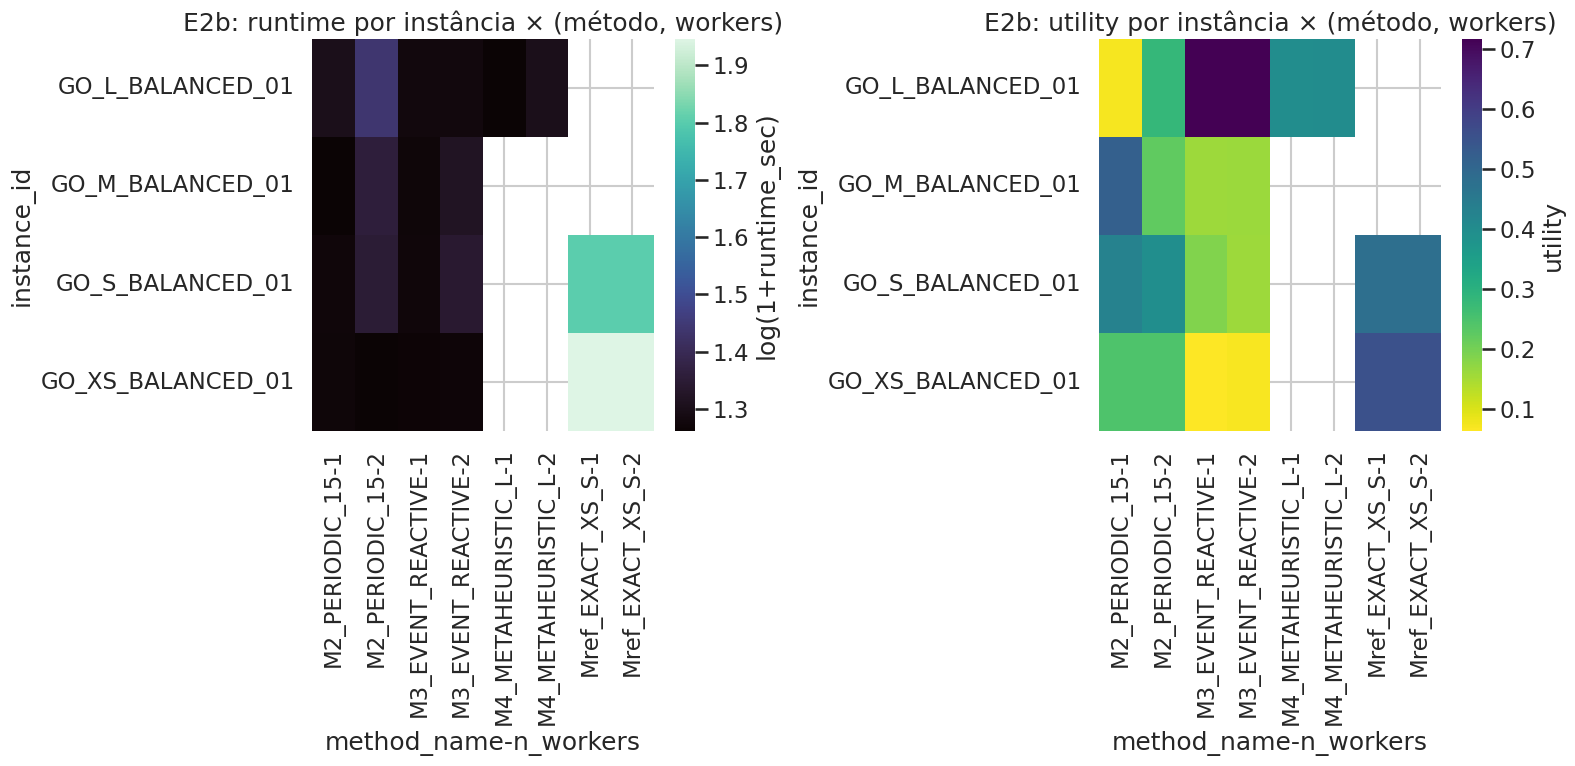

In [28]:
e2b_test_medium = e2b_sensitivity.loc[
    e2b_sensitivity["protocol_role"].eq("test")
    & e2b_sensitivity["budget_label"].eq("medium")
].copy()
runtime_heatmap = (
    e2b_test_medium
    .pivot_table(
        index="instance_id",
        columns=["method_name", "n_workers"],
        values="runtime_sec",
        aggfunc="mean",
    )
    .sort_index(axis=1)
)
utility_heatmap = (
    e2b_test_medium
    .pivot_table(
        index="instance_id",
        columns=["method_name", "n_workers"],
        values="utility",
        aggfunc="mean",
    )
    .sort_index(axis=1)
)
if runtime_heatmap.empty or utility_heatmap.empty:
    display(pd.DataFrame([{"warning": "Nao ha linhas suficientes para o heatmap E2b no recorte teste + medium."}]))
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    sns.heatmap(np.log1p(runtime_heatmap), cmap="mako", ax=axes[0], cbar_kws={"label": "log(1+runtime_sec)"})
    axes[0].set_title("E2b: runtime no teste por instância × (método, workers)")
    sns.heatmap(utility_heatmap, cmap="viridis_r", ax=axes[1], cbar_kws={"label": "utility"})
    axes[1].set_title("E2b: utility no teste por instância × (método, workers)")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [29]:
throughput_summary = (
    e2b_sensitivity.groupby(["protocol_role", "method_name", "budget_label", "n_workers"], as_index=False)
    .agg(
        runtime_sec=("runtime_sec", "median"),
        utility=("utility", "median"),
        plan_instability=("plan_instability", "mean"),
        selected_config=("selected_config", "max"),
    )
    .sort_values(["protocol_role", "method_name", "budget_label", "n_workers"])
)
display(throughput_summary)

,method_name,budget_label,n_workers,runtime_sec,utility,plan_instability
0,M2_PERIODIC_15,long,1,5.176323,0.128797,0.506510
1,M2_PERIODIC_15,long,2,5.116487,0.275494,0.766146
2,M2_PERIODIC_15,medium,1,2.566636,0.337155,0.000000
3,M2_PERIODIC_15,medium,2,2.865455,0.263374,0.489844
4,M2_PERIODIC_15,short,1,1.116270,0.487505,NaN
5,M2_PERIODIC_15,short,2,1.210619,0.636410,NaN
6,M3_EVENT_REACTIVE,long,1,5.044837,0.142317,0.497917
7,M3_EVENT_REACTIVE,long,2,5.131859,0.156877,0.466667
8,M3_EVENT_REACTIVE,medium,1,2.564834,0.172364,0.000000
9,M3_EVENT_REACTIVE,medium,2,2.662308,0.159185,0.234028


## E3. ISA, UMAP, HDBSCAN e solver footprints

O backend antigo já entregava `PCA`; aqui acrescentamos:

- `UMAP` para a geometria não linear;
- `HDBSCAN` para clusters e outliers;
- `solver footprints` via `utility <= best + ε`.

In [30]:
display(
    umap_frame[
        [
            "instance_id",
            "scale_code",
            "regime_code",
            "best_method",
            "difficulty",
            "cluster_label",
            "umap_x",
            "umap_y",
        ]
    ].sort_values(["best_method", "instance_id"])
)

,instance_id,scale_code,regime_code,best_method,difficulty,cluster_label,umap_x,umap_y
0,GO_L_BALANCED_01,L,balanced,M0_FIFO_OFFICIAL,easy,3,16.937265,2.081966
1,GO_L_BALANCED_02,L,balanced,M0_FIFO_OFFICIAL,easy,3,16.600466,1.885453
2,GO_L_BALANCED_03,L,balanced,M0_FIFO_OFFICIAL,easy,3,17.071585,1.819945
3,GO_L_DISRUPTED_01,L,disrupted,M0_FIFO_OFFICIAL,easy,1,14.426983,0.223435
4,GO_L_DISRUPTED_02,L,disrupted,M0_FIFO_OFFICIAL,easy,1,14.897729,0.625509
5,GO_L_DISRUPTED_03,L,disrupted,M0_FIFO_OFFICIAL,easy,1,14.936931,0.290750
6,GO_L_PEAK_01,L,peak,M0_FIFO_OFFICIAL,easy,2,15.951154,0.629913
7,GO_L_PEAK_02,L,peak,M0_FIFO_OFFICIAL,easy,2,15.966413,1.107792
8,GO_L_PEAK_03,L,peak,M0_FIFO_OFFICIAL,easy,2,16.523693,0.928409
9,GO_M_BALANCED_01,M,balanced,M0_FIFO_OFFICIAL,easy,3,16.845098,2.666700


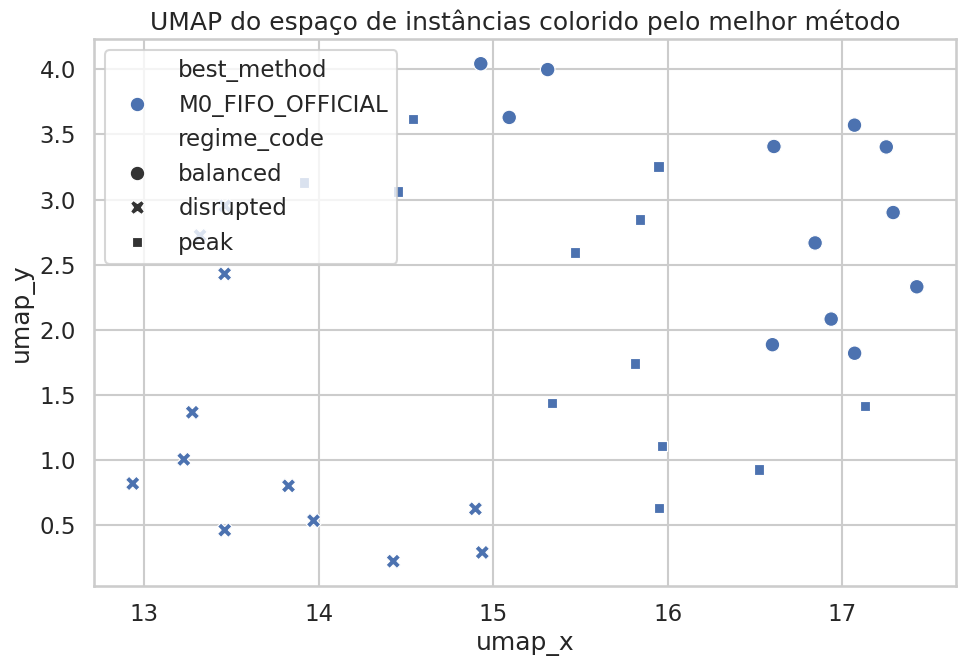

In [31]:
fig = paper.plot_umap_best_method(umap_frame)
plt.show()
plt.close(fig)


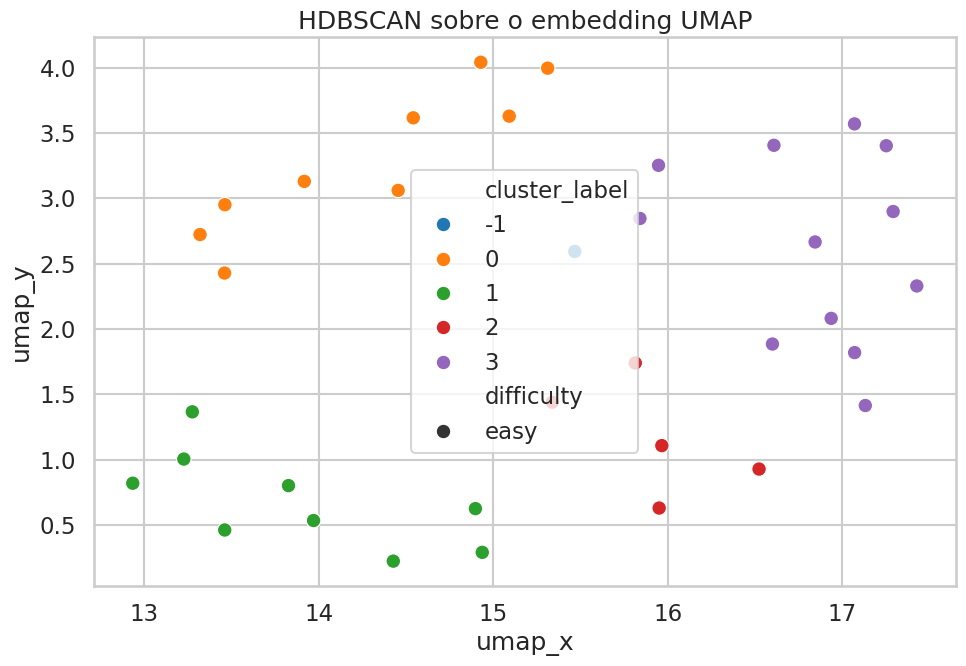

In [32]:
fig = paper.plot_hdbscan_clusters(umap_frame)
plt.show()
plt.close(fig)


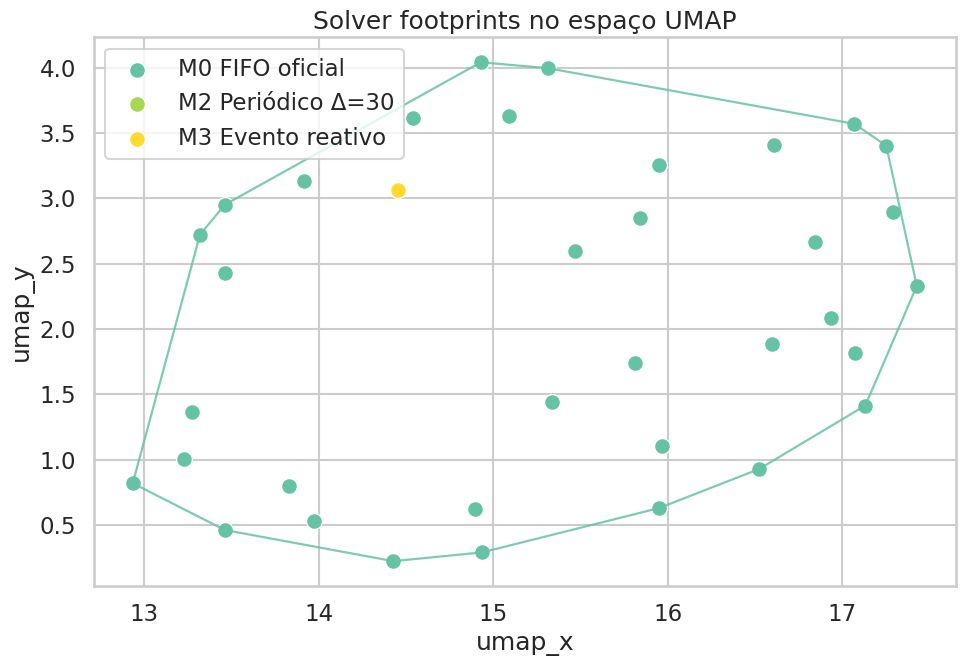

In [33]:
fig = paper.plot_solver_footprints(umap_frame, method_matrix)
plt.show()
plt.close(fig)


## E4. Selector, SHAP e exportação ASlib

Com apenas 36 instâncias, o selector continua **explicativo**, não um claim
forte de produção. Mesmo assim, ele fecha o protocolo:

- compara árvore, random forest e LightGBM quando disponível;
- exporta `features.csv`, `performance.csv`, `runstatus.csv`,
  `feature_costs.csv` e `cv.csv` em `catalog/aslib_scenario/`;
- salva o sumário de `SHAP` em `catalog/selector_shap_summary.csv`.

In [34]:
display(selector_report)
display(selector_shap[["feature_name", "mean_abs_shap", "selected_model"]].drop_duplicates().head(15))

aslib_paths_df = pd.DataFrame(
    [{"artifact_name": name, "path": str(path)} for name, path in paper_results.aslib_paths.items()]
)
display(aslib_paths_df)


,model_name,top1_accuracy,macro_f1,balanced_accuracy
0,decision_tree,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0
2,lightgbm,1.0,1.0,1.0


,feature_name,mean_abs_shap,selected_model
0,replicate,0.0,decision_tree
1,planning_horizon_min,0.0,decision_tree
2,n_jobs,0.0,decision_tree
3,appointment_share_x,0.0,decision_tree
4,urgent_share_x,0.0,decision_tree
5,contracted_share,0.0,decision_tree
6,commodity_nunique,0.0,decision_tree
7,moisture_nunique,0.0,decision_tree
8,load_mean,0.0,decision_tree
9,load_std,0.0,decision_tree


,artifact_name,path
0,features,/home/marcusvinicius/Repositorios/PequiFlux/ag...
1,performance,/home/marcusvinicius/Repositorios/PequiFlux/ag...
2,runstatus,/home/marcusvinicius/Repositorios/PequiFlux/ag...
3,feature_costs,/home/marcusvinicius/Repositorios/PequiFlux/ag...
4,cv,/home/marcusvinicius/Repositorios/PequiFlux/ag...


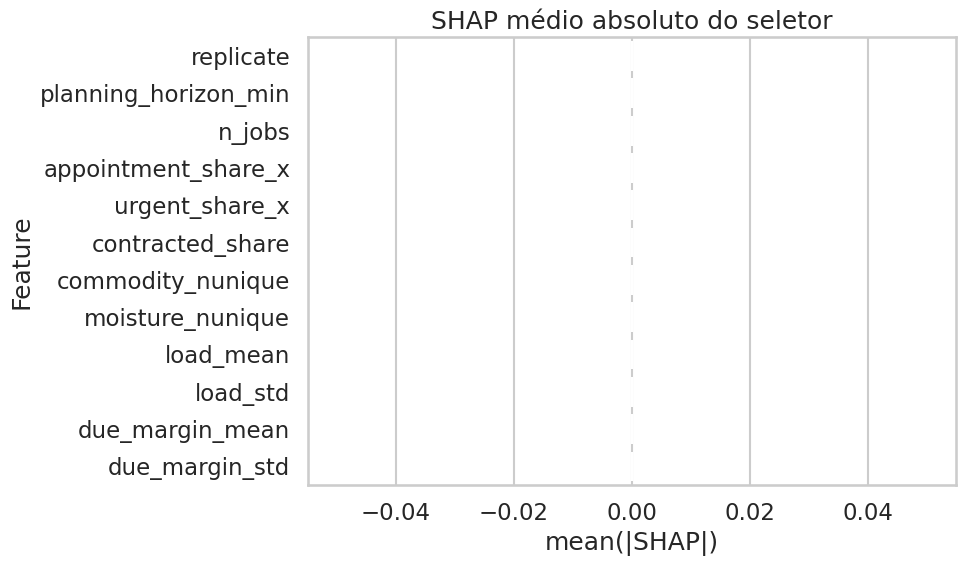

In [35]:
fig = paper.plot_selector_shap(selector_shap)
plt.show()
plt.close(fig)


## E5. Validade do benchmark sintético

Este bloco reúne os diagnósticos do paper para a qualidade do benchmark:

- `MMD/C2ST/density ratio`;
- scorecard consolidado;
- integridade relacional;
- checagem de caudas e segmentos raros;
- cobertura e redundância do espaço de instâncias.

In [36]:
e5_validity_snapshot = paper.build_e5_validity_snapshot(
    formal_shift_summary=formal_shift_summary,
    job_density_segments=job_density_segments,
    proc_density_segments=proc_density_segments,
    summary=summary,
    tail_regime_checks=tail_regime_checks,
    rare_segment_summary=rare_segment_summary,
    instance_space_summary=instance_space_summary,
)
display(e5_validity_snapshot)
display(scorecard_release)


,diagnostic_block,c2st_auc_mean,mmd_rbf_mean,mean_log_density_ratio
0,job_due_layer,0.777706,0.005687,0.992822
1,proc_time_layer,0.597995,0.000980,0.148676
2,instance_space,NaN,2.322821,0.666667
3,tail_checks,0.750000,0.750000,5.000000
4,scorecard_release,0.777706,0.597995,1.000000


,metric_name,metric_value
0,structural_pass_rate,1.0
1,release_consistency_checks_pass,0.0
2,flow_regime_order_checks_pass,1.0
3,instance_space_exact_duplicate_checks_pass,1.0
4,method_count,7.0
5,best_method_diversity,1.0
6,selector_top1_accuracy,1.0
7,selector_macro_f1,1.0


## E6. Instâncias `graded` e `discriminating`

A geração abaixo transforma as propostas do ISA em bundles concretos de
instâncias-filhas, com arquivos centrais de scheduling, eventos regenerados
e baseline FIFO replayado no próprio notebook.

In [37]:
child_proposals_path = REPO_ROOT / "catalog" / "graded_discriminating_candidates.csv"
if child_proposals_path.exists():
    child_instance_proposals = pd.read_csv(child_proposals_path)
else:
    child_instance_proposals = paper.build_child_instance_proposals(
        feature_frame=paper_features,
        performance=method_matrix,
        umap_frame=umap_frame,
    )
    child_instance_proposals.to_csv(child_proposals_path, index=False)
display(child_instance_proposals)


,candidate_id,child_type,instance_id,scale_code,regime_code,difficulty,best_method,spread,cluster_label,proposal_rule,target_recommendation
0,DISCRIMINATING_L_11,discriminating,GO_L_DISRUPTED_01,L,disrupted,easy,M0_FIFO_OFFICIAL,0.953877,1,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
1,DISCRIMINATING_L_12,discriminating,GO_L_PEAK_03,L,peak,easy,M0_FIFO_OFFICIAL,0.952849,2,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
2,DISCRIMINATING_M_09,discriminating,GO_M_BALANCED_03,M,balanced,easy,M0_FIFO_OFFICIAL,1.000000,3,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
3,DISCRIMINATING_M_10,discriminating,GO_M_DISRUPTED_01,M,disrupted,easy,M0_FIFO_OFFICIAL,1.000000,1,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
4,DISCRIMINATING_S_14,discriminating,GO_S_DISRUPTED_02,S,disrupted,easy,M0_FIFO_OFFICIAL,0.950644,1,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
5,DISCRIMINATING_S_13,discriminating,GO_S_PEAK_03,S,peak,easy,M0_FIFO_OFFICIAL,0.950649,3,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
6,DISCRIMINATING_XS_15,discriminating,GO_XS_PEAK_01,XS,peak,easy,M0_FIFO_OFFICIAL,0.950417,0,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
7,DISCRIMINATING_XS_16,discriminating,GO_XS_PEAK_02,XS,peak,easy,M0_FIFO_OFFICIAL,0.950413,0,expandir regiões com maior spread entre métodos,acentuar flexibilidade e regimes limítrofes on...
8,GRADED_L_01,graded,GO_L_BALANCED_01,L,balanced,easy,M0_FIFO_OFFICIAL,0.952774,3,interpolar dificuldade entre pais fáceis e dif...,"aumentar reveal_span, congestion_mean e downti..."
9,GRADED_L_02,graded,GO_L_BALANCED_02,L,balanced,easy,M0_FIFO_OFFICIAL,0.952762,3,interpolar dificuldade entre pais fáceis e dif...,"aumentar reveal_span, congestion_mean e downti..."


In [38]:
child_instance_dir = REPO_ROOT / "output" / "jupyter-notebook" / "generated_child_instances"
child_summary_path = REPO_ROOT / "catalog" / "graded_discriminating_children_summary.csv"
generated_child_summary = paper.load_or_generate_child_instances(
    root=ANALYSIS_ROOT,
    proposals=child_instance_proposals,
    out_dir=child_instance_dir,
    summary_path=child_summary_path,
)
display(generated_child_summary)


,candidate_id,child_type,parent_instance_id,output_dir,reveal_span_parent,reveal_span_child,congestion_mean_parent,congestion_mean_child,downtime_total_parent,downtime_total_child,eligibility_density_parent,eligibility_density_child,fifo_mean_flow_child,fifo_p95_flow_child,fifo_makespan_child,generated_file_count
0,DISCRIMINATING_L_11,discriminating,GO_L_DISRUPTED_01,/home/marcusvinicius/Repositorios/PequiFlux/ag...,542,542,0.712664,0.739530,171,229,3.6068,2.8672,641.302083,1067.75,1596.0,13
1,DISCRIMINATING_L_12,discriminating,GO_L_PEAK_03,/home/marcusvinicius/Repositorios/PequiFlux/ag...,625,625,0.664171,0.702383,0,68,3.5938,2.8411,710.208333,1075.75,1641.0,13
2,DISCRIMINATING_M_09,discriminating,GO_M_BALANCED_03,/home/marcusvinicius/Repositorios/PequiFlux/ag...,612,612,0.758091,0.784175,0,58,2.7448,2.2135,316.333333,456.95,1033.0,13
3,DISCRIMINATING_M_10,discriminating,GO_M_DISRUPTED_01,/home/marcusvinicius/Repositorios/PequiFlux/ag...,509,509,0.736041,0.778759,151,219,2.7344,2.1992,636.843750,1006.70,1532.0,13
4,DISCRIMINATING_S_13,discriminating,GO_S_PEAK_03,/home/marcusvinicius/Repositorios/PequiFlux/ag...,502,502,0.628421,0.663870,0,68,2.0875,1.7875,429.050000,696.45,1228.0,13
5,DISCRIMINATING_S_14,discriminating,GO_S_DISRUPTED_02,/home/marcusvinicius/Repositorios/PequiFlux/ag...,492,492,0.631618,0.654341,184,242,2.0562,1.7750,358.150000,604.60,1116.0,13
6,DISCRIMINATING_XS_15,discriminating,GO_XS_PEAK_01,/home/marcusvinicius/Repositorios/PequiFlux/ag...,528,528,0.579585,0.599001,0,58,1.6146,1.4062,239.250000,427.35,999.0,13
7,DISCRIMINATING_XS_16,discriminating,GO_XS_PEAK_02,/home/marcusvinicius/Repositorios/PequiFlux/ag...,558,558,0.656533,0.694144,0,68,1.6146,1.3854,249.250000,422.30,1019.0,13
8,GRADED_L_01,graded,GO_L_BALANCED_01,/home/marcusvinicius/Repositorios/PequiFlux/ag...,567,567,0.624051,0.665461,0,29,3.6285,3.6285,66.041667,102.35,671.0,13
9,GRADED_L_02,graded,GO_L_BALANCED_02,/home/marcusvinicius/Repositorios/PequiFlux/ag...,598,598,0.594889,0.655456,0,33,3.6042,3.6042,67.472222,103.45,686.0,13


## Resumo do escopo

O notebook cobre o `Artigo.md` com execução auditável por células e com o protocolo experimental alinhado ao texto do paper.

O conteúdo visível no notebook permanece sendo:

- métodos: `M0_FIFO_OFFICIAL`, `M1_WEIGHTED_SLACK`, `M2_PERIODIC_15`, `M2_PERIODIC_30`, `M3_EVENT_REACTIVE`, `Mref_EXACT_XS_S`, `M4_METAHEURISTIC_L`;
- experimentos: `E0`, `E1`, `E1b`, `E2`, `E2b`, `E3`, `E4`, `E5`, `E6`;
- protocolo de split: `R01` para calibração e `R02-R03` para teste, preservando as 12 famílias `escala x regime`;
- execução reativa: `M2` e `M3` seguem aparecendo aqui como replay online periódico ou por eventos;
- outputs do paper: tabelas, heatmaps, footprints, SHAP, ASlib, scorecards e bundles `graded/discriminating` renderizados ou referenciados no próprio notebook.

A biblioteca nova só removeu código de implementação do miolo do notebook. Ela não removeu o que você quer ver do `paper/Artigo.md`.
